# Homework 1: Autoregressive Generative Models

Recorded experimental notebook for binary MNIST PixelCNN. The 15 executed code cells and their original numerical/image outputs are retained; author identifiers and machine paths are removed. Path settings below write a new session to `runs/notebook-session/`. See `reproduce-experiments.ipynb` and the repository CLI to run all seven protocols, including the independent 25-epoch S0 experiment.

本作业包括二值自回归模型的负对数似然证明，以及 MNIST 上 PixelCNN 的实现、训练和图像生成。实验从标准网络出发，依次开展训练时长与超参数对照、网络结构对照和正则化续训；各阶段采用相同的数据划分与静态二值化协议。

实验编号为 S0（25 轮初始探索）、S1/S2/S3（三组标准网络）、G（双支路门控网络）、F0/F0.2（从 G 的最佳权重开始的两组正则化续训）。检查点与方案依据验证 NLL 选择，测试集用于评估所选模型。下面保留教师模板的原有章节，展示实现代码、各阶段记录、训练曲线和完整生成样本。

S0 的表格与曲线引用已完成的初步实验记录，其原始已执行 Notebook、权重和数据记录保存在实验存档。下面自含 S1/S2/S3、G、F0/F0.2 六组实验的完整训练代码。仅复制本文件到空目录重跑时，会重训这六组并省略 S0 历史曲线；本文件保存的执行输出包含全部阶段结果。

## 问题 1：负对数似然与交叉熵

**证明。** 设 $x_i\in\{0,1\}$，记 $x_{<i}=(x_1,\ldots,x_{i-1})$，并令 $\pi_i=p_\theta(X_i=1\mid x_{<i})$。则真实取值的条件概率为
$$p_\theta(X_i=x_i\mid x_{<i})=\pi_i^{x_i}(1-\pi_i)^{1-x_i}.$$
由概率链式法则及对数运算法则，
$$\begin{aligned}
\operatorname{NLL}(x)&=-\ln p_\theta(x)=-\ln\prod_{i=1}^{T}\pi_i^{x_i}(1-\pi_i)^{1-x_i}\\
&=-\sum_{i=1}^{T}\left[x_i\ln\pi_i+(1-x_i)\ln(1-\pi_i)\right]\\
&=\operatorname{CrossEntropy}(\pi,x).
\end{aligned}$$
其中真实标签 $y_i=x_i$，故负对数似然等于题目给定的交叉熵损失。证毕。

# **0. Load Preliminary Functions**

# a. Import Libraries and Functions

In [1]:
import os, sys, json, math, time, random, hashlib, csv, platform, itertools
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import MNIST
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

CONFIG = dict(seed=20260920, sample_seed=20260921, split_seed=20260920,
              channels=64, n_blocks=12, batch_size=256, epochs=100,
              lr=1e-3, min_lr=1e-5, grad_clip=1.0, threshold=128,
              n_train=55000, n_val=5000, n_test=10000, n_samples=64)
CONFIG['architecture'] = 'standard'
# Resolve the repository from its root or the notebooks directory.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / 'data'
OUT = PROJECT_ROOT / 'runs' / 'notebook-session'
OUT.mkdir(parents=True, exist_ok=True)
FIG = OUT / 'figures'
FIG.mkdir(exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(min(4, os.cpu_count() or 1))
# Fixed random seeds; CUDA/cuDNN versions may still cause small numerical differences.
def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all(CONFIG['seed'])
torch.backends.cudnn.benchmark = True
ENV = dict(python=sys.version.split()[0], torch=torch.__version__,
           torchvision=torchvision.__version__, numpy=np.__version__,
           matplotlib=matplotlib.__version__, cuda=torch.version.cuda,
           device=str(device), gpu=torch.cuda.get_device_name(0) if device.type == 'cuda' else None,
           platform=platform.platform(), started_utc=datetime.now(timezone.utc).isoformat())
print(json.dumps({'config': CONFIG, 'environment': ENV}, indent=2, ensure_ascii=False))
(OUT / 'config.json').write_text(json.dumps(CONFIG, indent=2), encoding='utf-8')
(OUT / 'environment.json').write_text(json.dumps(ENV, indent=2), encoding='utf-8')

from torchvision import datasets, transforms
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Liberation Serif', 'DejaVu Serif'],
    'mathtext.fontset': 'stix', 'font.size': 10, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.linewidth': 0.7, 'lines.linewidth': 1.2,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True, 'legend.frameon': False,
    'figure.dpi': 110, 'savefig.dpi': 400, 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

def show_grid(images, filename, ncols=8):
    array = images.detach().cpu().numpy()[:, 0]
    nrows = math.ceil(len(array)/ncols)
    fig, axes = plt.subplots(nrows,ncols,figsize=(5.8,5.8*nrows/ncols),squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color('0.78'); spine.set_linewidth(0.35)
        if i < len(array):
            ax.imshow(array[i],cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
        else:
            ax.axis('off')
    fig.subplots_adjust(left=0.005,right=0.995,bottom=0.005,top=0.995,wspace=0.06,hspace=0.06)
    fig.savefig(FIG/filename,dpi=400,bbox_inches='tight',pad_inches=0.015)
    fig.savefig((FIG/filename).with_suffix('.pdf'),bbox_inches='tight',pad_inches=0.015)
    plt.show(); plt.close(fig)

{
  "config": {
    "seed": 20260920,
    "sample_seed": 20260921,
    "split_seed": 20260920,
    "channels": 64,
    "n_blocks": 12,
    "batch_size": 256,
    "epochs": 100,
    "lr": 0.001,
    "min_lr": 1e-05,
    "grad_clip": 1.0,
    "threshold": 128,
    "n_train": 55000,
    "n_val": 5000,
    "n_test": 10000,
    "n_samples": 64,
    "architecture": "standard"
  },
  "environment": {
    "python": "3.9.23",
    "torch": "1.12.1+cu102",
    "torchvision": "0.13.1+cu102",
    "numpy": "1.23.5",
    "matplotlib": "3.9.4",
    "cuda": "10.2",
    "device": "cuda",
    "gpu": "NVIDIA TITAN RTX"
  }
}


# b. MNIST Data Loader

Training / validation / test: 55000 5000 10000
Binarization: pixel/255 > 0.5; input shape: (1, 28, 28)
MD5 checks: all four files passed.


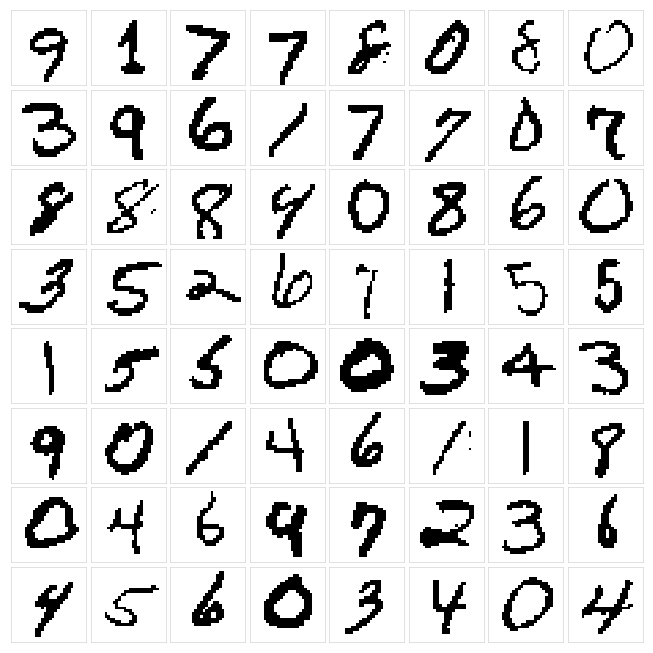

In [2]:
def binarize_image(tensor):
    return (tensor > 0.5).float()

tensor_transform = transforms.Compose([
    transforms.ToTensor(), transforms.Lambda(binarize_image)
])
MNIST.mirrors = ['https://ossci-datasets.s3.amazonaws.com/mnist/', 'http://yann.lecun.com/exdb/mnist/']
train_raw = MNIST(str(DATA_ROOT), train=True, download=True)
test_raw = MNIST(str(DATA_ROOT), train=False, download=True)
data_hashes = {}
for filename, expected in MNIST.resources:
    path = Path(train_raw.raw_folder) / filename
    if path.exists():
        actual = hashlib.md5(path.read_bytes()).hexdigest()
        assert actual == expected, f'MD5 mismatch: {filename}'
        data_hashes[filename] = actual
    else:
        # Some preinstalled Kaggle copies include only already extracted IDX files.
        raw_path = path.with_suffix('')
        assert raw_path.exists()
        data_hashes[raw_path.name + ' (sha256)'] = hashlib.sha256(raw_path.read_bytes()).hexdigest()
all_train_x = (train_raw.data >= CONFIG['threshold']).float().unsqueeze(1)
test_x = (test_raw.data >= CONFIG['threshold']).float().unsqueeze(1)
permutation = torch.randperm(60000, generator=torch.Generator().manual_seed(CONFIG['split_seed']))
train_idx, val_idx = permutation[:55000], permutation[55000:]
train_x, val_x = all_train_x[train_idx], all_train_x[val_idx]
assert len(set(train_idx.tolist()) & set(val_idx.tolist())) == 0
assert set(torch.unique(train_x).tolist()) == {0., 1.}
np.savez_compressed(OUT / 'split_indices.npz', train=train_idx.numpy(), val=val_idx.numpy())
(OUT / 'dataset_checksums.json').write_text(json.dumps(data_hashes, indent=2), encoding='utf-8')

# The same threshold as tensor_transform is precomputed once for faster loading.
assert torch.equal(binarize_image(train_raw.data[0].float()/255), all_train_x[0,0])
batch_size = CONFIG['batch_size']
train_dataset = TensorDataset(train_x, train_raw.targets[train_idx])
val_dataset = TensorDataset(val_x, train_raw.targets[val_idx])
test_dataset = TensorDataset(test_x, test_raw.targets)
loader_kwargs = dict(batch_size=batch_size,num_workers=0,pin_memory=device.type=='cuda')
shuffle_generator = torch.Generator().manual_seed(CONFIG['seed']+1)
train_loader = DataLoader(train_dataset,shuffle=True,generator=shuffle_generator,**loader_kwargs)
val_loader = DataLoader(val_dataset,shuffle=False,**loader_kwargs)
test_loader = DataLoader(test_dataset,shuffle=False,**loader_kwargs)
print('Training / validation / test:',len(train_dataset),len(val_dataset),len(test_dataset))
print('Binarization: pixel/255 > 0.5; input shape:',tuple(train_x.shape[1:]))
print('MD5 checks: all four files passed.')
show_grid(train_x[:64],'mnist_train.png')

# **1. PixelCNN**


# a. Training Function

`model.logits(x)` 返回用于计算损失的 logits，`model(x)` 返回 Bernoulli 概率，供条件预测和无条件采样使用。训练使用 `BCEWithLogitsLoss` 保证数值稳定<sup>[1]</sup>。平均 BCE 按像素统计；每图平均 NLL 为平均 BCE 的 784 倍，bits/pixel 为平均 BCE 除以 $\ln 2$。每轮遍历完整训练划分，以验证集 NLL 选择模型。

In [3]:
bce = F.binary_cross_entropy_with_logits

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    values = []
    for batch in loader:
        x = batch[0].to(device, non_blocking=True)
        logits = model.logits(x).float()
        values.append(bce(logits, x, reduction='none').flatten(1).sum(1).cpu())
    nll = torch.cat(values).double()
    mean = nll.mean().item()
    return dict(n=len(nll), nll_nats_per_image=mean, bce_nats_per_pixel=mean/784,
                bits_per_pixel=mean/(784*math.log(2)),
                standard_error=nll.std(unbiased=True).item()/math.sqrt(len(nll))), nll

def train(dataloader, model, optimizer, epochs, *, output_dir=None, resume=False):
    global history, training_summary
    output_dir = OUT if output_dir is None else Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    # All candidates follow the same 100-epoch schedule.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG['epochs'], eta_min=CONFIG['min_lr'])
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
    if resume:
        state = torch.load(output_dir/'training_state.pt', map_location=device)
        model.load_state_dict(state['model'])
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        scaler.load_state_dict(state['scaler'])
        dataloader.generator.set_state(state['shuffle_rng'].cpu())
        torch.set_rng_state(state['torch_rng'].cpu())
        if device.type == 'cuda':
            torch.cuda.set_rng_state_all([s.cpu() for s in state['cuda_rng']])
        history = state['history']
        initial, best, best_epoch = state['initial'], state['best'], state['best_epoch']
        first_epoch = state['epoch'] + 1
        prior_seconds = state['training_seconds']
    else:
        history = []
        best, best_epoch, first_epoch, prior_seconds = float('inf'), 0, 1, 0.
        initial, _ = evaluate(model, val_loader)
        print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
        print(f'Initial validation NLL: {initial["nll_nats_per_image"]:.4f}', flush=True)
    training_start = time.perf_counter()
    for epoch in range(first_epoch, epochs + 1):
        start = time.perf_counter()
        model.train()
        loss_sum, seen = 0., 0
        lr = optimizer.param_groups[0]['lr']
        for x, labels in dataloader:
            x = x.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=device.type == 'cuda'):
                loss = bce(model.logits(x), x)
            if not torch.isfinite(loss):
                raise RuntimeError('Nonfinite training loss')
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            loss_sum += loss.item() * len(x)
            seen += len(x)
        val, _ = evaluate(model, val_loader)
        record = dict(epoch=epoch, train_bce=loss_sum/seen, train_nll=loss_sum/seen*784,
                      val_bce=val['bce_nats_per_pixel'], val_nll=val['nll_nats_per_image'],
                      lr=lr, seconds=time.perf_counter()-start, train_images_seen=seen)
        assert seen == CONFIG['n_train']
        history.append(record)
        if record['val_nll'] < best:
            best, best_epoch = record['val_nll'], epoch
            torch.save({k:v.detach().cpu() for k,v in model.state_dict().items()},
                       output_dir/'pixelcnn_best.pt')
        if epoch in (1, 5, 10, 25, 50, 75, 100):
            torch.save({k:v.detach().cpu() for k,v in model.state_dict().items()},
                       output_dir/f'pixelcnn_epoch_{epoch:02d}.pt')
        scheduler.step()
        elapsed = prior_seconds + time.perf_counter()-training_start
        state = dict(model=model.state_dict(), optimizer=optimizer.state_dict(),
                     scheduler=scheduler.state_dict(), scaler=scaler.state_dict(),
                     shuffle_rng=dataloader.generator.get_state(), torch_rng=torch.get_rng_state(),
                     cuda_rng=torch.cuda.get_rng_state_all() if device.type=='cuda' else [],
                     history=history, initial=initial, best=best, best_epoch=best_epoch,
                     epoch=epoch, training_seconds=elapsed)
        torch.save(state, output_dir/'training_state.pt')
        with (output_dir/'history.csv').open('w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=list(record))
            writer.writeheader(); writer.writerows(history)
        (output_dir/'training_progress.json').write_text(json.dumps(dict(
            best_epoch=best_epoch, best_val_nll=best, completed_epoch=epoch,
            initial_validation=initial, training_seconds=elapsed), indent=2))
        print(f'Epoch {epoch:03d}/{CONFIG["epochs"]}: train NLL={record["train_nll"]:.3f}, '
              f'val NLL={record["val_nll"]:.3f}, lr={lr:.6f}, {record["seconds"]:.1f}s', flush=True)
    elapsed = prior_seconds + time.perf_counter()-training_start
    model.load_state_dict(torch.load(output_dir/'pixelcnn_best.pt', map_location=device))
    training_summary = dict(best_epoch=best_epoch, best_val_nll=best,
                           initial_validation=initial, training_seconds=elapsed,
                           parameter_count=sum(p.numel() for p in model.parameters()))
    (output_dir/'training_summary.json').write_text(json.dumps(training_summary, indent=2))
    return [row['train_bce'] for row in history]

# b. Masked Convolution

In [4]:
"""Causal binary PixelCNN."""
import torch
from torch import nn
from torch.nn import functional as F


class MaskedConv2d(nn.Conv2d):
    """Raster-order masked convolution for single-channel image generation."""

    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if mask_type not in ("A", "B"):
            raise ValueError("mask_type must be A or B")
        kh, kw = self.kernel_size
        if kh % 2 == 0 or kw % 2 == 0:
            raise ValueError("The spatial kernel sizes must be odd")
        if self.stride != (1, 1) or self.padding_mode != "zeros":
            raise ValueError("Use stride=1 and zero padding to preserve raster causality")
        expected_padding = tuple(d * (k // 2) for d, k in zip(self.dilation, self.kernel_size))
        if self.padding != expected_padding:
            raise ValueError("Use centered same padding")
        self.mask_type = mask_type
        mask = torch.ones_like(self.weight)
        mask[:, :, kh // 2 + 1:, :] = 0
        mask[:, :, kh // 2, kw // 2 + (mask_type == "B"):] = 0
        self.register_buffer("mask", mask)

    def forward(self, x):
        # Multiplication is in the autograd graph: masked weights get zero gradient.
        # Never mutate self.weight.data inside forward().
        return F.conv2d(x, self.weight * self.mask, self.bias,
                        self.stride, self.padding, self.dilation, self.groups)

# c. Model

In [5]:
class ChannelLayerNorm(nn.Module):
    """Normalize channels at each (batch, row, column), never across pixels."""

    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        return self.norm(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)


class CausalResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = ChannelLayerNorm(channels)
        self.conv = MaskedConv2d("B", channels, channels, 3, padding=1)

    def forward(self, x):
        return x + self.conv(F.relu(self.norm(x)))


class PixelCNN(nn.Module):
    def __init__(self, channels=64, n_blocks=12):
        super().__init__()
        self.input_conv = MaskedConv2d("A", 1, channels, 7, padding=3)
        self.blocks = nn.Sequential(*[CausalResidualBlock(channels) for _ in range(n_blocks)])
        self.head = nn.Sequential(
            ChannelLayerNorm(channels), nn.ReLU(),
            MaskedConv2d("B", channels, channels, 1), nn.ReLU(),
            MaskedConv2d("B", channels, 1, 1),
        )

    def logits(self, x):
        """Unnormalized conditional logits for numerically stable training."""
        return self.head(self.blocks(self.input_conv(x)))

    def forward(self, x):
        """Conditional Bernoulli probabilities, as used by the course template."""
        return torch.sigmoid(self.logits(x))

"""Two-stream gated PixelCNN with a full causal context on 28x28 images."""
import torch
from torch import nn



class VerticalConv2d(MaskedConv2d):
    """A excludes the current row; B includes the entire hidden-feature row."""

    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(mask_type, *args, **kwargs)
        center = self.kernel_size[0] // 2
        self.mask.zero_()
        self.mask[:, :, :center + (mask_type == 'B'), :] = 1


def gated_activation(value):
    signal, gate = value.chunk(2, dim=1)
    return torch.tanh(signal) * torch.sigmoid(gate)


class GatedCausalBlock(nn.Module):
    def __init__(self, channels, dilation):
        super().__init__()
        self.vertical_norm = ChannelLayerNorm(channels)
        self.horizontal_norm = ChannelLayerNorm(channels)
        self.vertical_conv = VerticalConv2d(
            'B', channels, 2*channels, 3, padding=dilation, dilation=dilation)
        self.horizontal_conv = MaskedConv2d(
            'B', channels, 2*channels, (1, 3),
            padding=(0, dilation), dilation=(1, dilation))
        self.vertical_to_horizontal = nn.Conv2d(2*channels, 2*channels, 1)
        self.horizontal_projection = nn.Conv2d(channels, channels, 1)

    def forward(self, vertical, horizontal):
        vertical_pre = self.vertical_conv(self.vertical_norm(vertical))
        horizontal_pre = self.horizontal_conv(self.horizontal_norm(horizontal))
        horizontal_pre = horizontal_pre + self.vertical_to_horizontal(vertical_pre)
        next_vertical = gated_activation(vertical_pre)
        next_horizontal = horizontal + self.horizontal_projection(
            gated_activation(horizontal_pre))
        return next_vertical, next_horizontal


class GatedPixelCNN(nn.Module):
    def __init__(self, channels=64, n_blocks=12, dilations=None):
        super().__init__()
        self.dilations = tuple(dilations or [1, 2, 4]*4)
        if len(self.dilations) != n_blocks or any(d < 1 for d in self.dilations):
            raise ValueError('Provide one positive dilation for each block')
        self.vertical_input = VerticalConv2d('A', 1, 2*channels, 7, padding=3)
        self.horizontal_input = MaskedConv2d(
            'A', 1, 2*channels, (1, 7), padding=(0, 3))
        self.input_vertical_to_horizontal = nn.Conv2d(2*channels, 2*channels, 1)
        self.blocks = nn.ModuleList([
            GatedCausalBlock(channels, d) for d in self.dilations])
        self.head = nn.Sequential(
            ChannelLayerNorm(channels), nn.ReLU(),
            MaskedConv2d('B', channels, channels, 1), nn.ReLU(),
            MaskedConv2d('B', channels, 1, 1))

    def logits(self, x):
        vertical_pre = self.vertical_input(x)
        horizontal_pre = self.horizontal_input(x)
        horizontal_pre = horizontal_pre + self.input_vertical_to_horizontal(vertical_pre)
        vertical = gated_activation(vertical_pre)
        horizontal = gated_activation(horizontal_pre)
        for block in self.blocks:
            vertical, horizontal = block(vertical, horizontal)
        return self.head(horizontal)

    def forward(self, x):
        return torch.sigmoid(self.logits(x))


"""Residual dropout, parameter averaging, and bounded validation-based fine-tuning.

This source can be executed directly in the course notebook namespace. It uses
the existing GatedPixelCNN, training data, evaluate(), and validation loader.
"""
import copy
import hashlib
import math
from contextlib import nullcontext


class RegularizedGatedPixelCNN(GatedPixelCNN):
    def __init__(self, channels=64, n_blocks=12, dilations=None, dropout_p=.2):
        super().__init__(channels, n_blocks, dilations)
        if not 0 <= dropout_p < 1:
            raise ValueError('dropout_p must be in [0, 1)')
        self.dropout_p = float(dropout_p)
        for block in self.blocks:
            block.horizontal_dropout = nn.Dropout(self.dropout_p)

    @staticmethod
    def _gate(value):
        signal, gate = value.chunk(2, dim=1)
        return torch.tanh(signal) * torch.sigmoid(gate)

    def logits(self, x):
        vertical_pre = self.vertical_input(x)
        horizontal_pre = self.horizontal_input(x)
        horizontal_pre = horizontal_pre + self.input_vertical_to_horizontal(vertical_pre)
        vertical = self._gate(vertical_pre)
        horizontal = self._gate(horizontal_pre)
        for block in self.blocks:
            vertical_pre = block.vertical_conv(block.vertical_norm(vertical))
            horizontal_pre = block.horizontal_conv(block.horizontal_norm(horizontal))
            horizontal_pre = horizontal_pre + block.vertical_to_horizontal(vertical_pre)
            vertical = self._gate(vertical_pre)
            residual = block.horizontal_dropout(self._gate(horizontal_pre))
            horizontal = horizontal + block.horizontal_projection(residual)
        return self.head(horizontal)


@torch.no_grad()
def update_parameter_average(averaged_model, raw_model, decay=.999):
    if not 0 <= decay < 1:
        raise ValueError('EMA decay must be in [0, 1)')
    raw_parameters = dict(raw_model.named_parameters())
    for name, value in averaged_model.named_parameters():
        value.mul_(decay).add_(raw_parameters[name], alpha=1-decay)
    raw_buffers = dict(raw_model.named_buffers())
    for name, value in averaged_model.named_buffers():
        value.copy_(raw_buffers[name])


def _initial_weights_fingerprint(state_dict):
    digest = hashlib.sha256()
    for name in sorted(state_dict):
        value = state_dict[name].detach().cpu().contiguous()
        digest.update(name.encode('utf-8'))
        digest.update(str(value.dtype).encode('ascii'))
        digest.update(str(tuple(value.shape)).encode('ascii'))
        digest.update(value.numpy().tobytes())
    return digest.hexdigest()


def train_finetuning(dataloader, model, optimizer, max_epochs, output_dir,
                    initial_state_dict, resume=False):
    """Warm-start weights and select initial, raw, or EMA by validation NLL.

    A finished run is restored without additional training. The optional
    CONFIG['pause_after_epoch'] stops at a complete-epoch checkpoint without
    marking the run finished; it is useful for checking interrupted execution.
    """
    global history, training_summary
    if max_epochs < 1:
        raise ValueError('max_epochs must be positive')
    if dataloader.generator is None:
        raise ValueError('Use an explicit DataLoader generator for exact resume')
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    decay = float(CONFIG.get('ema_decay', .999))
    patience = int(CONFIG.get('early_stop_patience', 5))
    min_delta = float(CONFIG.get('early_stop_min_delta', .02))
    if not 0 <= decay < 1 or patience < 1 or min_delta < 0:
        raise ValueError('Invalid averaging or early-stop settings')
    scheduler_settings = dict(mode='min', factor=float(CONFIG.get('plateau_factor', .5)),
                              patience=int(CONFIG.get('plateau_patience', 2)),
                              threshold=float(CONFIG.get('plateau_threshold', .02)),
                              threshold_mode='abs', min_lr=float(CONFIG.get('min_lr', 1e-5)))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, **scheduler_settings)
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
    averaged_model = copy.deepcopy(model).eval()
    for parameter in averaged_model.parameters():
        parameter.requires_grad_(False)
    settings = dict(
        initial_weights_sha256=_initial_weights_fingerprint(initial_state_dict),
        channels=model.vertical_input.out_channels//2, n_blocks=len(model.blocks),
        dilations=list(model.dilations), dropout_p=model.dropout_p,
        ema_decay=decay, early_stop_patience=patience, early_stop_min_delta=min_delta,
        max_epochs=int(max_epochs), scheduler=scheduler_settings,
        initial_lr=[group['lr'] for group in optimizer.param_groups],
        optimizer=optimizer.__class__.__name__, optimizer_defaults=copy.deepcopy(optimizer.defaults),
        batch_size=dataloader.batch_size,
        grad_clip=float(CONFIG.get('grad_clip', 1.)),
        n_train=CONFIG['n_train'], n_val=CONFIG['n_val'],
        seed=CONFIG.get('seed'), split_seed=CONFIG.get('split_seed'),
        threshold=CONFIG.get('threshold'))
    history_fields = ['epoch','train_bce','train_nll','val_nll','raw_val_nll',
                      'ema_val_nll','lr','seconds','train_images_seen','val_source']
    best_path = output_dir/'pixelcnn_best.pt'
    state_path = output_dir/'training_state.pt'

    def save_best(chosen):
        torch.save({name:value.detach().cpu() for name,value in chosen.state_dict().items()}, best_path)

    def write_history():
        with (output_dir/'history.csv').open('w', newline='', encoding='utf-8') as file:
            writer = csv.DictWriter(file, fieldnames=history_fields)
            writer.writeheader()
            writer.writerows(history)

    if resume:
        state = torch.load(state_path, map_location=device)
        assert state['settings'] == settings, 'Fine-tuning configuration or initial weights changed'
        model.load_state_dict(state['model'])
        averaged_model.load_state_dict(state['ema_model'])
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        scaler.load_state_dict(state['scaler'])
        dataloader.generator.set_state(state['shuffle_rng'].cpu())
        torch.set_rng_state(state['torch_rng'].cpu())
        if device.type == 'cuda':
            torch.cuda.set_rng_state_all([value.cpu() for value in state['cuda_rng']])
        history = state['history']
        initial = state['initial']
        best, best_epoch, best_source = state['best'], state['best_epoch'], state['best_source']
        significant_best, bad_epochs = state['significant_best'], state['bad_epochs']
        completed = state['epoch']
        successful_steps, attempted_steps = state['successful_steps'], state['attempted_steps']
        prior_seconds = state['training_seconds']
        finished, stop_reason = state['finished'], state['stop_reason']
    else:
        model.load_state_dict(initial_state_dict)
        averaged_model.load_state_dict(initial_state_dict)
        initial, _ = evaluate(model, val_loader)
        assert initial['n'] == CONFIG['n_val']
        if 'initial_val_nll' in CONFIG:
            assert abs(initial['nll_nats_per_image']-CONFIG['initial_val_nll']) < 1e-5
        best = significant_best = initial['nll_nats_per_image']
        scheduler.step(best)
        best_epoch, best_source, bad_epochs, completed = 0, 'initial', 0, 0
        successful_steps, attempted_steps, prior_seconds = 0, 0, 0.
        finished, stop_reason = False, 'running'
        initial_train = CONFIG.get('initial_train_nll')
        initial_bce = (initial_train/CONFIG.get('image_numel',784)
                       if initial_train is not None else None)
        history = [dict(epoch=0, train_bce=initial_bce, train_nll=initial_train,
                        val_nll=best, raw_val_nll=best, ema_val_nll=best,
                        lr=0., seconds=0., train_images_seen=0, val_source='initial')]
        save_best(model)
        write_history()
        print(f'Fine-tuning initial validation NLL: {best:.6f}', flush=True)

    training_start = time.perf_counter()

    def save_state():
        elapsed = prior_seconds+time.perf_counter()-training_start
        state = dict(model=model.state_dict(), ema_model=averaged_model.state_dict(),
                     optimizer=optimizer.state_dict(), scheduler=scheduler.state_dict(),
                     scaler=scaler.state_dict(), settings=settings,
                     shuffle_rng=dataloader.generator.get_state(), torch_rng=torch.get_rng_state(),
                     cuda_rng=torch.cuda.get_rng_state_all() if device.type=='cuda' else [],
                     history=history, initial=initial, best=best, best_epoch=best_epoch,
                     best_source=best_source, significant_best=significant_best, bad_epochs=bad_epochs,
                     epoch=completed, training_seconds=elapsed, max_epochs=max_epochs,
                     successful_steps=successful_steps, attempted_steps=attempted_steps,
                     finished=finished, stop_reason=stop_reason)
        torch.save(state, state_path)
        (output_dir/'training_progress.json').write_text(json.dumps(dict(
            completed_epoch=completed, best_epoch=best_epoch, best_source=best_source,
            best_val_nll=best, significant_best=significant_best, bad_epochs=bad_epochs,
            successful_steps=successful_steps, attempted_steps=attempted_steps,
            finished=finished, stop_reason=stop_reason, training_seconds=elapsed), indent=2))
        return elapsed

    last_elapsed = prior_seconds
    if not resume:
        last_elapsed = save_state()
    if not finished:
        for epoch in range(completed+1, max_epochs+1):
            epoch_start = time.perf_counter()
            model.train()
            loss_sum, seen, pixels_per_image = 0., 0, None
            lr = optimizer.param_groups[0]['lr']
            for batch in dataloader:
                images = batch[0].to(device, non_blocking=True)
                if pixels_per_image is None:
                    pixels_per_image = images[0].numel()
                assert images[0].numel() == pixels_per_image
                optimizer.zero_grad(set_to_none=True)
                with (torch.cuda.amp.autocast() if device.type == 'cuda' else nullcontext()):
                    loss = F.binary_cross_entropy_with_logits(model.logits(images), images)
                if not torch.isfinite(loss):
                    raise RuntimeError('Nonfinite fine-tuning loss')
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), settings['grad_clip'])
                previous_scale = scaler.get_scale()
                scaler.step(optimizer)
                scaler.update()
                attempted_steps += 1
                # An overflow reduces the scale and skips Adam. Successful updates
                # keep or grow the scale; only those updates advance the EMA.
                if scaler.get_scale() >= previous_scale:
                    successful_steps += 1
                    update_parameter_average(averaged_model, model, decay)
                loss_sum += loss.item()*len(images)
                seen += len(images)
            assert seen == CONFIG['n_train']
            raw_validation, _ = evaluate(model, val_loader)
            ema_validation, _ = evaluate(averaged_model, val_loader)
            assert raw_validation['n'] == ema_validation['n'] == CONFIG['n_val']
            raw_value = raw_validation['nll_nats_per_image']
            ema_value = ema_validation['nll_nats_per_image']
            if not math.isfinite(raw_value) or not math.isfinite(ema_value):
                raise RuntimeError('Nonfinite validation NLL')
            value, source = (raw_value, 'raw') if raw_value <= ema_value else (ema_value, 'ema')
            if value < best:
                best, best_epoch, best_source = value, epoch, source
                save_best(model if source == 'raw' else averaged_model)
            if significant_best-value > min_delta:
                significant_best, bad_epochs = value, 0
            else:
                bad_epochs += 1
            record = dict(epoch=epoch, train_bce=loss_sum/seen,
                          train_nll=loss_sum/seen*pixels_per_image,
                          val_nll=value, raw_val_nll=raw_value, ema_val_nll=ema_value,
                          lr=lr, seconds=time.perf_counter()-epoch_start,
                          train_images_seen=seen, val_source=source)
            history.append(record)
            completed = epoch
            if epoch == 1:
                torch.save({name:value.detach().cpu() for name,value in model.state_dict().items()},
                           output_dir/'pixelcnn_epoch_01.pt')
            scheduler.step(value)
            finished = bad_epochs >= patience or completed >= max_epochs
            stop_reason = ('early_stop' if bad_epochs >= patience else
                           'max_epochs' if completed >= max_epochs else 'running')
            pause_after = CONFIG.get('pause_after_epoch')
            if not finished and pause_after is not None and completed >= pause_after:
                stop_reason = 'paused'
            write_history()
            last_elapsed = save_state()
            print(f'Fine-tuning {epoch:02d}/{max_epochs}: train NLL={record["train_nll"]:.6f}, '
                  f'raw val={raw_value:.6f}, EMA val={ema_value:.6f}, '
                  f'best={best:.6f} ({best_source}), lr={lr:.6g}, '
                  f'{record["seconds"]:.1f}s', flush=True)
            if finished or stop_reason == 'paused':
                break

    elapsed = last_elapsed
    assert len(history)-1 == completed
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()
    training_summary = dict(best_epoch=best_epoch, best_source=best_source,
                           best_val_nll=best, initial_validation=initial,
                           completed_epochs=completed, max_epochs=max_epochs,
                           finished=finished, stop_reason=stop_reason,
                           training_seconds=elapsed, ema_decay=decay,
                           dropout_p=model.dropout_p,
                           parameter_count=sum(value.numel() for value in model.parameters()),
                           successful_steps=successful_steps, attempted_steps=attempted_steps,
                           successful_step_fraction=successful_steps/attempted_steps if attempted_steps else 1.)
    (output_dir/'training_summary.json').write_text(json.dumps(training_summary, indent=2))
    return training_summary


# d. Training

### 掩码与因果性检查

首层使用 A 型掩码，排除当前像素；后续隐藏层使用 B 型掩码，保留同一位置已有的因果特征<sup>[2]</sup>。以下检查掩码取值、卷积输出和梯度，并通过扰动当前及未来像素检验因果性。

In [6]:
y = torch.tensor([0., 1., 1., 0.], dtype=torch.float64)
z = torch.tensor([-1.7, 0.2, 2.1, -0.4], dtype=torch.float64, requires_grad=True)
prob = z.sigmoid()
nll = -(prob.pow(y) * (1 - prob).pow(1 - y)).log().sum()
bce_sum = F.binary_cross_entropy_with_logits(z, y, reduction='sum')
ce = F.cross_entropy(torch.stack([torch.zeros_like(z), z], dim=1), y.long(), reduction='sum')
grad_nll, = torch.autograd.grad(nll, z, retain_graph=True)
grad_bce_sum, = torch.autograd.grad(bce_sum, z)
assert torch.allclose(nll, bce_sum, atol=1e-12, rtol=0)
assert torch.allclose(ce, bce_sum, atol=1e-12, rtol=0)
assert torch.allclose(grad_nll, grad_bce_sum, atol=1e-12, rtol=0)
extreme_z = torch.tensor([-1000., 1000.])
assert torch.isfinite(F.binary_cross_entropy_with_logits(extreme_z, torch.tensor([1., 0.])) )
print(f'NLL(sum)={nll.item():.12f}; BCE(sum)={bce_sum.item():.12f}; CE(sum)={ce.item():.12f}')
print('梯度一致；极端 logits 的 BCEWithLogitsLoss 仍为有限值。')

NLL(sum)=1.394459674348; BCE(sum)=1.394459674348; CE(sum)=1.394459674348
梯度一致；极端 logits 的 BCEWithLogitsLoss 仍为有限值。


{
  "mask_values_forward_gradient_and_validation": "PASS",
  "train_and_eval_causality_max_abs_error": 0.0,
  "future_input_gradient": 0.0,
  "batch_independence": "PASS",
  "sum_of_all_2x2_image_probabilities": 0.9999999999999998
}


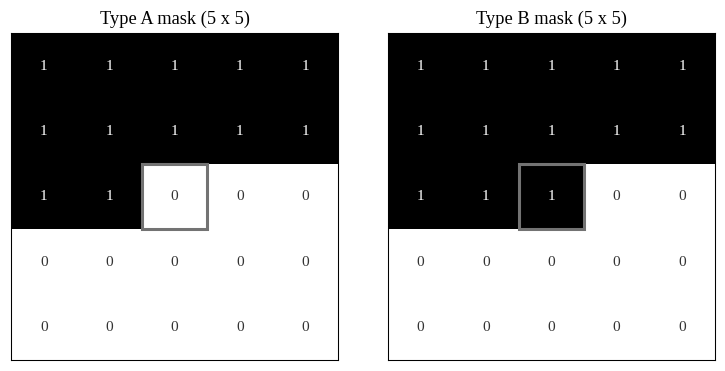

Gated network checks: {
  "gated_mask_values": "PASS",
  "gated_structural_coverage": {
    "positions_checked": 784,
    "leakage_positions": 0,
    "missing_past_positions": 0,
    "bottom_right_past_pixels": 783
  },
  "gated_train_and_eval_causality_max_abs_error": 0.0,
  "gated_future_input_gradient": 0.0,
  "gated_batch_independence": "PASS",
  "gated_sum_of_all_2x2_image_probabilities": 0.9999999999999998
}


In [7]:
def run_correctness_checks():
    results = {}
    torch.manual_seed(7)
    expected_a = torch.tensor([[1,1,1],[1,0,0],[0,0,0]], dtype=torch.float32)
    expected_b = torch.tensor([[1,1,1],[1,1,0],[0,0,0]], dtype=torch.float32)
    for mask_type, expected in [('A', expected_a), ('B', expected_b)]:
        layer = MaskedConv2d(mask_type, 1, 1, 3, padding=1, bias=False)
        assert torch.equal(layer.mask[0, 0], expected)
        with torch.no_grad():
            layer.weight.fill_(1.)
        x = torch.arange(25.).reshape(1,1,5,5)
        observed = layer(x)[0,0,2,2].item()
        expected_value = 6 + 7 + 8 + 11 + (12 if mask_type == 'B' else 0)
        assert observed == expected_value
        layer(x).sum().backward()
        assert torch.count_nonzero(layer.weight.grad[layer.mask == 0]).item() == 0
    rect = MaskedConv2d('A', 1, 2, (3,5), padding=(1,2))
    assert rect.mask[0,0].sum().item() == 7
    for args in [('C',3,1), ('A',2,1), ('A',3,0)]:
        try:
            MaskedConv2d(args[0],1,1,args[1],padding=args[2])
        except ValueError:
            pass
        else:
            raise AssertionError('Invalid arguments accepted')
    results['mask_values_forward_gradient_and_validation'] = 'PASS'

    # Use float64 on CPU to make the causality test independent of GPU roundoff.
    probe = PixelCNN(channels=8, n_blocks=3).double()
    x = torch.randn(2,1,8,8,dtype=torch.float64)
    worst = 0.
    for mode in (True, False):
        probe.train(mode)
        for t in (0,1,7,8,27,35,63):
            modified = x.clone()
            modified.flatten(1)[:,t:] = torch.randn_like(modified.flatten(1)[:,t:])
            with torch.no_grad():
                original = probe.logits(x).flatten(1)[:,:t+1]
                changed = probe.logits(modified).flatten(1)[:,:t+1]
            delta = (original - changed).abs().max().item()
            worst = max(worst, delta)
            assert delta < 1e-12
        probe_input = x.clone().requires_grad_(True)
        grad, = torch.autograd.grad(probe.logits(probe_input).flatten(1)[0,35], probe_input)
        assert torch.count_nonzero(grad.flatten(1)[0,35:]).item() == 0
        assert grad.flatten(1)[0,:35].abs().sum().item() > 0
        modified_batch = x.clone()
        modified_batch[1] = torch.randn_like(x[1])
        assert torch.allclose(probe.logits(x)[0], probe.logits(modified_batch)[0], atol=1e-12, rtol=0)
    results['train_and_eval_causality_max_abs_error'] = worst
    results['future_input_gradient'] = 0.0
    results['batch_independence'] = 'PASS'
    # Exhaustively enumerate the joint distribution on a tiny 2x2 image.
    bits = torch.tensor(list(itertools.product([0.,1.], repeat=4)), dtype=torch.float64).reshape(16,1,2,2)
    with torch.no_grad():
        log_joint = -F.binary_cross_entropy_with_logits(probe.logits(bits), bits, reduction='none').flatten(1).sum(1)
        total_probability = log_joint.exp().sum().item()
    assert abs(total_probability - 1.) < 1e-12
    results['sum_of_all_2x2_image_probabilities'] = total_probability
    print(json.dumps(results, ensure_ascii=False, indent=2))
    return results

CHECKS = run_correctness_checks()
(OUT / 'correctness_checks.json').write_text(json.dumps(CHECKS, indent=2), encoding='utf-8')
fig, axes = plt.subplots(1,2,figsize=(7,3.4))
for ax, typ in zip(axes, ('A','B')):
    mask = MaskedConv2d(typ,1,1,5,padding=2).mask[0,0].numpy()
    ax.imshow(mask, vmin=0, vmax=1, cmap='Greys')
    for r in range(5):
        for c in range(5):
            ax.text(c,r,str(int(mask[r,c])),ha='center',va='center',color='white' if mask[r,c] else '#333333')
    ax.add_patch(plt.Rectangle((1.5,1.5),1,1,fill=False,edgecolor='0.45',lw=2))
    ax.set_title(f'Type {typ} mask (5 x 5)')
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
fig.savefig(FIG / 'masks.png',dpi=400,bbox_inches='tight')
plt.show(); plt.close(fig)

"""Causality and structural coverage checks for the two-stream network."""
import itertools
import json
import torch
from torch.nn import functional as F


def check_structural_coverage(height=28, width=28, dilations=None):
    dilations = list(dilations or [1, 2, 4]*4)
    inputs = [[1 << (r*width+c) for c in range(width)] for r in range(height)]

    def expand(grid, offsets):
        result = [[0]*width for _ in range(height)]
        for r in range(height):
            for c in range(width):
                value = 0
                for dr, dc in offsets:
                    rr, cc = r+dr, c+dc
                    if 0 <= rr < height and 0 <= cc < width:
                        value |= grid[rr][cc]
                result[r][c] = value
        return result

    vertical = expand(inputs, [(dr, dc) for dr in (-3, -2, -1) for dc in range(-3, 4)])
    horizontal = expand(inputs, [(0, dc) for dc in (-3, -2, -1)])
    horizontal = [[h | v for h, v in zip(hr, vr)]
                  for hr, vr in zip(horizontal, vertical)]
    for d in dilations:
        vertical = expand(vertical, [(dr, dc) for dr in (-d, 0) for dc in (-d, 0, d)])
        horizontal = expand(horizontal, [(0, -d), (0, 0)])
        horizontal = [[h | v for h, v in zip(hr, vr)]
                      for hr, vr in zip(horizontal, vertical)]
    leakage, missing = 0, 0
    for r in range(height):
        for c in range(width):
            index = r*width+c
            expected = (1 << index)-1
            leakage += bool(horizontal[r][c] & ~expected)
            missing += bool(expected & ~horizontal[r][c])
    assert leakage == missing == 0
    return dict(positions_checked=height*width, leakage_positions=leakage,
                missing_past_positions=missing,
                bottom_right_past_pixels=bin(horizontal[-1][-1]).count('1'))


def run_gated_checks(model_class):
    torch.manual_seed(11)
    model = model_class(8, 12).double()
    expected_vertical_a = torch.zeros(7, 7, dtype=torch.float64)
    expected_vertical_a[:3] = 1
    assert torch.equal(model.vertical_input.mask[0,0], expected_vertical_a)
    assert torch.equal(model.horizontal_input.mask[0,0],
                       torch.tensor([[1,1,1,0,0,0,0]], dtype=torch.float64))
    for block, dilation in zip(model.blocks, model.dilations):
        assert block.vertical_conv.dilation == (dilation, dilation)
        assert block.horizontal_conv.dilation == (1, dilation)
        assert torch.equal(block.vertical_conv.mask[0,0],
            torch.tensor([[1,1,1],[1,1,1],[0,0,0]], dtype=torch.float64))
        assert torch.equal(block.horizontal_conv.mask[0,0],
            torch.tensor([[1,1,0]], dtype=torch.float64))
    x = torch.randn(2, 1, 28, 28, dtype=torch.float64)
    worst = 0.
    for training in (True, False):
        model.train(training)
        for index in (0, 1, 27, 28, 35, 200, 392, 755, 783):
            altered = x.clone()
            altered.flatten(1)[:, index:] = torch.randn_like(altered.flatten(1)[:, index:])
            with torch.no_grad():
                original = model.logits(x).flatten(1)[:, :index+1]
                changed = model.logits(altered).flatten(1)[:, :index+1]
            error = (original-changed).abs().max().item()
            worst = max(worst, error)
            assert error < 1e-12
        variable = x.clone().requires_grad_(True)
        gradient, = torch.autograd.grad(model.logits(variable).flatten(1)[0, 392], variable)
        assert torch.count_nonzero(gradient.flatten(1)[0, 392:]).item() == 0
        assert gradient.flatten(1)[0, :392].abs().sum().item() > 0
        other_batch = x.clone()
        other_batch[1] = torch.randn_like(other_batch[1])
        with torch.no_grad():
            assert torch.allclose(model.logits(x)[0], model.logits(other_batch)[0], atol=1e-12, rtol=0)
    bits = torch.tensor(list(itertools.product([0., 1.], repeat=4)),
                        dtype=torch.float64).reshape(16, 1, 2, 2)
    with torch.no_grad():
        log_joint = -F.binary_cross_entropy_with_logits(
            model.logits(bits), bits, reduction='none').flatten(1).sum(1)
        total = log_joint.exp().sum().item()
    assert abs(total-1) < 1e-12
    return dict(gated_mask_values='PASS',
                gated_structural_coverage=check_structural_coverage(dilations=model.dilations),
                gated_train_and_eval_causality_max_abs_error=worst,
                gated_future_input_gradient=0., gated_batch_independence='PASS',
                gated_sum_of_all_2x2_image_probabilities=total)




CHECKS.update(run_gated_checks(GatedPixelCNN))
(OUT/'correctness_checks.json').write_text(json.dumps(CHECKS, indent=2))
print('Gated network checks:', json.dumps({k:v for k,v in CHECKS.items() if k.startswith('gated_')}, indent=2))


In [8]:
import shutil

CANDIDATES = [
    dict(name='lr1e-3_bs256', lr=1e-3, batch_size=256),
    dict(name='lr1e-3_bs128', lr=1e-3, batch_size=128),
    dict(name='lr5e-4_bs128', lr=5e-4, batch_size=128),
]
tuning_results = []
tuning_start = time.perf_counter()
for candidate in CANDIDATES:
    print('\nCandidate:', candidate, flush=True)
    CONFIG.update(lr=candidate['lr'], batch_size=candidate['batch_size'])
    seed_all(CONFIG['seed'])
    generator = torch.Generator().manual_seed(CONFIG['seed'] + 1)
    candidate_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                                 shuffle=True, generator=generator, num_workers=0,
                                 pin_memory=device.type == 'cuda')
    candidate_dir = OUT/'tuning'/candidate['name']
    candidate_dir.mkdir(parents=True, exist_ok=True)
    marker = candidate_dir/'worker.pid'
    while marker.exists():
        worker_pid = int(marker.read_text())
        try:
            os.kill(worker_pid, 0)
        except ProcessLookupError:
            marker.unlink(missing_ok=True)
            break
        time.sleep(2)
    model = PixelCNN(CONFIG['channels'], CONFIG['n_blocks']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
    resumed = (candidate_dir/'training_state.pt').exists()
    if resumed:
        print('Restoring an existing training state for this candidate.', flush=True)
    train(candidate_loader, model, optimizer, CONFIG['epochs'],
          output_dir=candidate_dir, resume=resumed)
    result = dict(**candidate, trained_epochs=CONFIG['epochs'],
                  best_val_nll=training_summary['best_val_nll'],
                  best_epoch=training_summary['best_epoch'],
                  training_seconds=training_summary['training_seconds'])
    tuning_results.append(result)
    (OUT/'tuning_summary.json').write_text(json.dumps(dict(
        trial_epochs=CONFIG['epochs'], results=tuning_results), indent=2))
    del model, optimizer, candidate_loader
    if device.type == 'cuda':
        torch.cuda.empty_cache()

selected = min(tuning_results, key=lambda r:r['best_val_nll'])
print('\nSelected by validation NLL:', selected, flush=True)
CONFIG.update(lr=selected['lr'], batch_size=selected['batch_size'])
(OUT/'config.json').write_text(json.dumps(CONFIG, indent=2))
loader_kwargs = dict(batch_size=CONFIG['batch_size'], num_workers=0,
                     pin_memory=device.type == 'cuda')
shuffle_generator = torch.Generator().manual_seed(CONFIG['seed'] + 1)
train_loader = DataLoader(train_dataset, shuffle=True, generator=shuffle_generator, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)
selected_dir = OUT/'tuning'/selected['name']
model = PixelCNN(CONFIG['channels'], CONFIG['n_blocks']).to(device)
model.load_state_dict(torch.load(selected_dir/'pixelcnn_best.pt', map_location=device))
with (selected_dir/'history.csv').open() as f:
    history = [{key:(int(value) if key in ('epoch','train_images_seen') else float(value))
                for key,value in row.items()} for row in csv.DictReader(f)]
training_summary = json.loads((selected_dir/'training_summary.json').read_text())
log = [row['train_bce'] for row in history]
for saved in selected_dir.iterdir():
    if saved.is_file() and (saved.suffix in ('.pt', '.csv', '.json')):
        shutil.copy2(saved, OUT/saved.name)
tuning_summary = dict(trial_epochs=CONFIG['epochs'], results=tuning_results,
                      selected=selected, final_epochs=CONFIG['epochs'],
                      final_best_epoch=training_summary['best_epoch'],
                      final_best_val_nll=training_summary['best_val_nll'],
                      elapsed_seconds=time.perf_counter()-tuning_start,
                      total_training_seconds=sum(r['training_seconds'] for r in tuning_results))
(OUT/'tuning_summary.json').write_text(json.dumps(tuning_summary, indent=2))
table = '| Initial LR | Batch size | Epochs | Best validation NLL |\n|---:|---:|---:|---:|\n'
for result in tuning_results:
    table += f'| {result["lr"]:.4g} | {result["batch_size"]} | {CONFIG["epochs"]} | {result["best_val_nll"]:.4f} |\n'
display(Markdown(table))
print(json.dumps(tuning_summary, indent=2))

# Preserve the selected standard model and its metrics before the structure trial.
standard_dir = OUT/'standard_run'
standard_dir.mkdir(exist_ok=True)
standard_config = dict(CONFIG)
standard_metrics = dict(
    train=evaluate(model, DataLoader(train_dataset, shuffle=False, **loader_kwargs))[0],
    validation=evaluate(model, val_loader)[0],
    **training_summary)
(standard_dir/'metrics.json').write_text(json.dumps(standard_metrics, indent=2))
(standard_dir/'config.json').write_text(json.dumps(standard_config, indent=2))
for name in ('pixelcnn_best.pt', 'pixelcnn_epoch_01.pt', 'history.csv', 'training_summary.json',
             'pixelcnn_epoch_05.pt', 'pixelcnn_epoch_10.pt', 'pixelcnn_epoch_25.pt',
             'pixelcnn_epoch_50.pt', 'pixelcnn_epoch_75.pt', 'pixelcnn_epoch_100.pt',
             'training_state.pt'):
    if (OUT/name).exists():
        shutil.copy2(OUT/name, standard_dir/name)



Candidate: {'name': 'lr1e-3_bs256', 'lr': 0.001, 'batch_size': 256}


Restoring an existing training state for this candidate.



Candidate: {'name': 'lr1e-3_bs128', 'lr': 0.001, 'batch_size': 128}


Restoring an existing training state for this candidate.



Candidate: {'name': 'lr5e-4_bs128', 'lr': 0.0005, 'batch_size': 128}


Restoring an existing training state for this candidate.



Selected by validation NLL: {'name': 'lr1e-3_bs128', 'lr': 0.001, 'batch_size': 128, 'trained_epochs': 100, 'best_val_nll': 60.46418600654602, 'best_epoch': 47, 'training_seconds': 6141.62527545169}


| Initial LR | Batch size | Epochs | Best validation NLL |
|---:|---:|---:|---:|
| 0.001 | 256 | 100 | 60.5759 |
| 0.001 | 128 | 100 | 60.4642 |
| 0.0005 | 128 | 100 | 60.5535 |


{
  "trial_epochs": 100,
  "results": [
    {
      "name": "lr1e-3_bs256",
      "lr": 0.001,
      "batch_size": 256,
      "trained_epochs": 100,
      "best_val_nll": 60.57585177135468,
      "best_epoch": 68,
      "training_seconds": 4428.487195970491
    },
    {
      "name": "lr1e-3_bs128",
      "lr": 0.001,
      "batch_size": 128,
      "trained_epochs": 100,
      "best_val_nll": 60.46418600654602,
      "best_epoch": 47,
      "training_seconds": 6141.62527545169
    },
    {
      "name": "lr5e-4_bs128",
      "lr": 0.0005,
      "batch_size": 128,
      "trained_epochs": 100,
      "best_val_nll": 60.55347481307983,
      "best_epoch": 45,
      "training_seconds": 3927.416102086194
    }
  ],
  "selected": {
    "name": "lr1e-3_bs128",
    "lr": 0.001,
    "batch_size": 128,
    "trained_epochs": 100,
    "best_val_nll": 60.46418600654602,
    "best_epoch": 47,
    "training_seconds": 6141.62527545169
  },
  "final_epochs": 100,
  "final_best_epoch": 47,
  "final_best_

### 网络结构对照：S2 与 G

标准网络的超参数对照选择 S2（学习率 0.001、批量大小 128）。该结构沿因果方向最多访问前 15 行，并存在右上方盲区。门控模型 G 以垂直支路表示上方行的信息，以水平支路表示本行左侧信息，两支路只允许垂直向水平传递。门控激活为 $\tanh(a)\odot\sigma(b)$，12 个块的膨胀率采用 $[1,2,4]\times4$，使 28×28 图像中的每个输出具有覆盖全部合法历史像素的结构路径<sup>[3]</sup>。

S2 与 G 均采用 64 通道、12 个隐藏块和逐位置通道归一化，使用相同的学习率与批量大小，以及 100 轮余弦退火计划。S2 使用卷积残差块；G 使用双支路门控块，仅水平支路采用恒等残差连接。两种结构的检查点分别按验证 NLL 选择。该对照比较完整网络方案：支路结构、门控、膨胀率和参数量同时发生变化。

In [9]:
ARCH_CONFIG = dict(standard_config, architecture='dilated_gated',
                   channels=64, n_blocks=12, dilations=[1,2,4]*4,
                   lr=1e-3, batch_size=128, epochs=100, min_lr=1e-5)
CONFIG.update(ARCH_CONFIG)
architecture_dir = OUT/'architecture/dilated_gated'
architecture_dir.mkdir(parents=True, exist_ok=True)
saved_config = architecture_dir/'config.json'
if (architecture_dir/'training_state.pt').exists():
    existing = json.loads(saved_config.read_text())
    for key in ('architecture','channels','n_blocks','dilations','batch_size','epochs',
                'lr','min_lr','seed','split_seed','grad_clip','threshold'):
        assert existing[key] == ARCH_CONFIG[key], 'Resume configuration changed: '+key
(architecture_dir/'config.json').write_text(json.dumps(ARCH_CONFIG, indent=2))
loader_kwargs = dict(batch_size=128, num_workers=0, pin_memory=device.type=='cuda')
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)
seed_all(CONFIG['seed'])
architecture_loader = DataLoader(train_dataset, shuffle=True,
    generator=torch.Generator().manual_seed(CONFIG['seed']+1), **loader_kwargs)
model = GatedPixelCNN(64, 12, ARCH_CONFIG['dilations']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
train(architecture_loader, model, optimizer, CONFIG['epochs'],
      output_dir=architecture_dir,
      resume=(architecture_dir/'training_state.pt').exists())
improved_summary = dict(training_summary)
selected_architecture = ('dilated_gated' if improved_summary['best_val_nll'] <
                         standard_metrics['best_val_nll'] else 'standard')
# Inspect the trained gated model even if validation selection falls back to standard.
gated_trained_errors = {}
causal_input = train_x[:2].to(device)
for training in (True, False):
    model.train(training)
    worst = 0.
    for index in (0,27,28,200,392,783):
        altered = causal_input.clone()
        altered.flatten(1)[:,index:] = 1-altered.flatten(1)[:,index:]
        with torch.no_grad():
            original = model.logits(causal_input).flatten(1)[:,:index+1]
            changed = model.logits(altered).flatten(1)[:,:index+1]
        worst = max(worst, (original-changed).abs().max().item())
        assert worst < 1e-5
    variable = causal_input.clone().requires_grad_(True)
    gradient, = torch.autograd.grad(model.logits(variable).flatten(1)[0,392], variable)
    assert torch.count_nonzero(gradient.flatten(1)[0,392:]).item() == 0
    gated_trained_errors['train' if training else 'eval'] = worst
CHECKS['gated_trained_28x28_prefix_max_error'] = gated_trained_errors
CHECKS['gated_trained_future_input_gradient'] = 0.
(OUT/'correctness_checks.json').write_text(json.dumps(CHECKS, indent=2))
print('Trained gated model causality:', gated_trained_errors)
baseline_model = PixelCNN(standard_config['channels'], standard_config['n_blocks']).to(device)
baseline_model.load_state_dict(torch.load(standard_dir/'pixelcnn_best.pt', map_location=device))
standard_metrics['test'] = evaluate(baseline_model, test_loader)[0]
(standard_dir/'metrics.json').write_text(json.dumps(standard_metrics, indent=2))
del baseline_model
improved_metrics = dict(
    train=evaluate(model, DataLoader(train_dataset, shuffle=False, **loader_kwargs))[0],
    validation=evaluate(model, val_loader)[0], test=evaluate(model, test_loader)[0],
    **improved_summary)
(architecture_dir/'metrics.json').write_text(json.dumps(improved_metrics, indent=2))

# The selection above uses validation NLL only, before test scores or samples.
architecture_summary = dict(epochs=100, dilations=ARCH_CONFIG['dilations'],
    selection_basis='validation_nll', selected=selected_architecture,
    selected_model='gated' if selected_architecture=='dilated_gated' else 'standard',
    selected_name='Dilated gated PixelCNN' if selected_architecture=='dilated_gated' else 'Standard PixelCNN',
    baseline=dict(name='standard', artifact_dir='standard_run', config=standard_config,
        metrics=standard_metrics, best_val_nll=standard_metrics['best_val_nll'],
        best_epoch=standard_metrics['best_epoch'], parameter_count=standard_metrics['parameter_count']),
    improved=dict(name='dilated_gated', artifact_dir='architecture/dilated_gated', config=ARCH_CONFIG,
        metrics=improved_metrics, best_val_nll=improved_summary['best_val_nll'],
        best_epoch=improved_summary['best_epoch'], parameter_count=improved_summary['parameter_count']))
(OUT/'architecture_summary.json').write_text(json.dumps(architecture_summary, indent=2))
selected_dir = architecture_dir if selected_architecture=='dilated_gated' else standard_dir
CONFIG.clear()
CONFIG.update(ARCH_CONFIG if selected_architecture=='dilated_gated' else standard_config)
(OUT/'config.json').write_text(json.dumps(CONFIG, indent=2))
model = (GatedPixelCNN(CONFIG['channels'], CONFIG['n_blocks'], CONFIG['dilations'])
         if selected_architecture=='dilated_gated' else PixelCNN(CONFIG['channels'], CONFIG['n_blocks'])).to(device)
model.load_state_dict(torch.load(selected_dir/'pixelcnn_best.pt', map_location=device))
with (selected_dir/'history.csv').open() as file:
    history = [{k:(int(v) if k in ('epoch','train_images_seen') else float(v))
                for k,v in row.items()} for row in csv.DictReader(file)]
training_summary = json.loads((selected_dir/'training_summary.json').read_text())
for name in ('pixelcnn_best.pt','pixelcnn_epoch_01.pt','history.csv','training_summary.json',
             'pixelcnn_epoch_05.pt','pixelcnn_epoch_10.pt','pixelcnn_epoch_25.pt',
             'pixelcnn_epoch_50.pt','pixelcnn_epoch_75.pt','pixelcnn_epoch_100.pt','training_state.pt'):
    if (selected_dir/name).exists():
        shutil.copy2(selected_dir/name, OUT/name)
table = '| Model | Parameters | Best epoch | Validation NLL | Test NLL |\n|---|---:|---:|---:|---:|\n'
for label, values in [('Standard',standard_metrics),('Dilated gated',improved_metrics)]:
    table += f'| {label} | {values["parameter_count"]} | {values["best_epoch"]} | {values["validation"]["nll_nats_per_image"]:.4f} | {values["test"]["nll_nats_per_image"]:.4f} |\n'
display(Markdown(table))
print('Selected architecture by validation NLL:', selected_architecture)

Trained gated model causality: {'train': 0.0, 'eval': 0.0}


| Model | Parameters | Best epoch | Validation NLL | Test NLL |
|---|---:|---:|---:|---:|
| Standard | 452225 | 47 | 60.4642 | 60.4827 |
| Dilated gated | 1462145 | 9 | 55.1815 | 55.3111 |


Selected architecture by validation NLL: dilated_gated


### 正则化续训对照：F0 与 F0.2

G 在第 9 轮取得最低验证 NLL，随后出现训练损失下降而验证损失上升的过拟合现象。以 G 第 9 轮的检查点作为共同起点，重新建立 Adam 优化器，使用学习率 $10^{-4}$、批量大小 128 开展两组续训。F0 的 Dropout 为 0；F0.2 在水平残差支路的门控激活后、投影前加入 $p=0.2$ 的 Dropout。两组的恒等残差和纵向支路相同，输出采用二值 Bernoulli 分布，训练目标为 BCE。残差支路正则化参考 PixelCNN++<sup>[5]</sup>。

两组均维护衰减率 0.999 的指数移动平均（EMA），逐轮比较原始参数 raw 与 EMA 的验证 NLL。ReduceLROnPlateau 的 patience 为 2，绝对改善阈值为 0.02 nats/image，学习率减半，下限为 $10^{-5}$；连续 5 轮没有超过该阈值的改善时提前停止，最多追加 20 轮。检查点保存依据实际最低验证 NLL，不受 0.02 阈值限制。追加轮 0 表示共同起点，没有执行参数更新；该起点也参与检查点选择。

F0 和 F0.2 分别完成 8 与 9 轮追加训练。方案和权重类型在测试集评估前确定，所选模型为 F0.2 的追加第 4 轮 EMA 权重。

In [10]:
import copy
initial_entry = copy.deepcopy(architecture_summary['improved'])
initial_entry['training_summary'] = json.loads((architecture_dir/'training_summary.json').read_text())
initial_weights = torch.load(architecture_dir/'pixelcnn_best.pt', map_location='cpu')
initial_sha = hashlib.sha256((architecture_dir/'pixelcnn_best.pt').read_bytes()).hexdigest()
fine_entries = []
fine_base = dict(ARCH_CONFIG, epochs=20, lr=1e-4, min_lr=1e-5,
    ema_decay=.999, early_stop_patience=5, early_stop_min_delta=.02,
    plateau_patience=2, initial_epoch=9,
    initial_train_nll=initial_entry['metrics']['train']['nll_nats_per_image'],
    initial_weights_sha256=initial_sha)
for name, dropout in [('finetune_control',0.),('finetune_dropout',.2)]:
    candidate_config = dict(fine_base, training_variant=name, dropout_p=dropout)
    directory = OUT/'finetuning'/name
    directory.mkdir(parents=True, exist_ok=True)
    if (directory/'training_state.pt').exists():
        assert json.loads((directory/'config.json').read_text()) == candidate_config
    (directory/'config.json').write_text(json.dumps(candidate_config, indent=2))
    CONFIG.clear(); CONFIG.update(candidate_config)
    seed_all(CONFIG['seed'])
    kwargs = dict(batch_size=128, num_workers=0, pin_memory=device.type=='cuda')
    val_loader = DataLoader(val_dataset, shuffle=False, **kwargs)
    test_loader = DataLoader(test_dataset, shuffle=False, **kwargs)
    fine_loader = DataLoader(train_dataset, shuffle=True,
        generator=torch.Generator().manual_seed(CONFIG['seed']+1), **kwargs)
    candidate_model = RegularizedGatedPixelCNN(64,12,CONFIG['dilations'],dropout).to(device)
    candidate_optimizer = torch.optim.Adam(candidate_model.parameters(), lr=CONFIG['lr'])
    summary = train_finetuning(fine_loader,candidate_model,candidate_optimizer,20,
        output_dir=directory,initial_state_dict=initial_weights,
        resume=(directory/'training_state.pt').exists())
    fine_entries.append(dict(name=name,artifact_dir='finetuning/'+name,
        config=candidate_config,training_summary=summary))
    del candidate_model,candidate_optimizer
# Freeze selection using validation scores before fine-tuning test evaluation or sampling.
winner = min(fine_entries,key=lambda e:e['training_summary']['best_val_nll'])
selected_fine = (winner['name'] if winner['training_summary']['best_val_nll'] <
                 initial_entry['best_val_nll'] else 'dilated_gated')
for entry in fine_entries:
    cfg=entry['config'];directory=OUT/entry['artifact_dir']
    candidate_model=RegularizedGatedPixelCNN(64,12,cfg['dilations'],cfg['dropout_p']).to(device)
    candidate_model.load_state_dict(torch.load(directory/'pixelcnn_best.pt',map_location=device))
    entry['metrics']=dict(train=evaluate(candidate_model,DataLoader(train_dataset,shuffle=False,**kwargs))[0],
        validation=evaluate(candidate_model,val_loader)[0],test=evaluate(candidate_model,test_loader)[0],
        **entry['training_summary'])
    (directory/'metrics.json').write_text(json.dumps(entry['metrics'],indent=2))
    del candidate_model
selected_entry = (winner if selected_fine!='dilated_gated' else initial_entry)
finetuning_summary=dict(selection_basis='validation_nll',selected=selected_fine,
    initialization=initial_entry,candidates=fine_entries,selected_entry=selected_entry)
(OUT/'finetuning_summary.json').write_text(json.dumps(finetuning_summary,indent=2))
CONFIG.clear(); CONFIG.update(selected_entry['config'])
(OUT/'config.json').write_text(json.dumps(CONFIG,indent=2))
chosen_dir=OUT/selected_entry['artifact_dir']
model=RegularizedGatedPixelCNN(64,12,CONFIG['dilations'],CONFIG.get('dropout_p',0.)).to(device)
model.load_state_dict(torch.load(chosen_dir/'pixelcnn_best.pt',map_location=device))
with (chosen_dir/'history.csv').open() as file:
    history=[{k:(int(v) if k in ('epoch','train_images_seen') else v if k=='val_source' else float(v))
              for k,v in row.items()} for row in csv.DictReader(file)]
training_summary=selected_entry['training_summary']
for name in ('pixelcnn_best.pt','pixelcnn_epoch_01.pt','history.csv','training_summary.json','training_state.pt'):
    shutil.copy2(chosen_dir/name,OUT/name)
if selected_fine!='dilated_gated':
    for epoch in (5,10,25,50,75,100):
        target=OUT/f'pixelcnn_epoch_{epoch:02d}.pt'
        if target.exists():target.unlink()
display(Markdown('| Continuation | Completed extra epochs | Best extra epoch | Weights | Validation NLL | Test NLL |\n'
    '|---|---:|---:|---|---:|---:|\n'+''.join(
    f'| {e["name"]} | {e["training_summary"]["completed_epochs"]} | {e["training_summary"]["best_epoch"]} | '
    f'{e["training_summary"]["best_source"]} | {e["metrics"]["validation"]["nll_nats_per_image"]:.4f} | '
    f'{e["metrics"]["test"]["nll_nats_per_image"]:.4f} |\n' for e in fine_entries)))
print('Selected continuation by validation NLL:',selected_fine)

| Continuation | Completed extra epochs | Best extra epoch | Weights | Validation NLL | Test NLL |
|---|---:|---:|---|---:|---:|
| finetune_control | 8 | 3 | ema | 54.5623 | 54.6944 |
| finetune_dropout | 9 | 4 | ema | 54.4841 | 54.6024 |


Selected continuation by validation NLL: finetune_dropout


### 各阶段训练过程与似然评估

第一幅图展示 S0、S1/S2/S3 与 G 的训练历程，第二幅图展示 F0/F0.2 的续训历程。各组曲线分开记录：S0 与 S1 使用不同的余弦退火周期，S1/S2/S3 为独立候选；F0/F0.2 从 G 第 9 轮检查点出发，不连接 G 第 100 轮的参数。

NLL 使用自然对数并按每幅图求和；BCE 按每像素平均。曲线中的训练损失为在线统计，表中的训练、验证和测试结果为固定检查点评估。独立 Bernoulli 基线仅用训练划分估计参数。

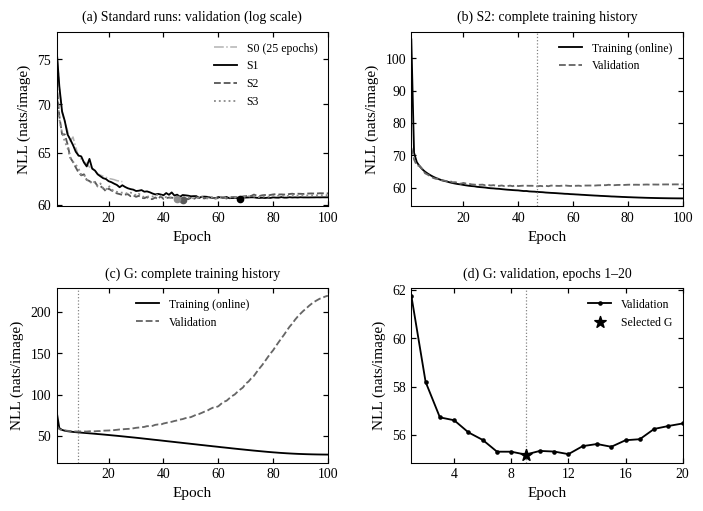

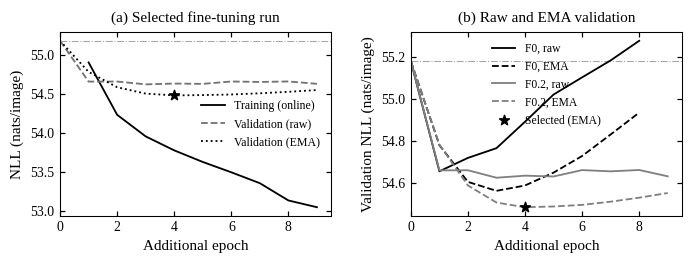

In [11]:
from matplotlib.ticker import MaxNLocator

def stage_history_figure(artifact_dir):
    """Plot saved S0/S1/S2/S3/G histories without fitting or mutating records."""
    from pathlib import Path
    artifact_dir=Path(artifact_dir)
    architecture=json.loads((artifact_dir/'architecture_summary.json').read_text())
    tuning=json.loads((artifact_dir/'tuning_summary.json').read_text())
    def history_at(directory):
        with (directory/'history.csv').open() as source:
            return [{key:float(row[key]) for key in ['epoch','train_nll','val_nll']}
                    for row in csv.DictReader(source)]
    fig,axes=plt.subplots(2,2,figsize=(6.5,4.75))
    if (artifact_dir/'previous_run/history.csv').exists():
        rows=history_at(artifact_dir/'previous_run')
        axes[0,0].plot([r['epoch'] for r in rows],[r['val_nll'] for r in rows],
                       color='0.7',ls='-.',lw=1,label='S0 (25 epochs)')
    standard_histories={}
    for index,(entry,style,color) in enumerate(zip(tuning['results'],['-','--',':'],['black','0.35','0.55']),1):
        rows=history_at(artifact_dir/'tuning'/entry['name'])
        standard_histories[entry['name']]=rows
        axes[0,0].plot([r['epoch'] for r in rows],[r['val_nll'] for r in rows],
                       color=color,ls=style,label=f'S{index}')
        axes[0,0].scatter([entry['best_epoch']],[entry['best_val_nll']],
                          color=color,s=16,marker='o',zorder=5)
    selected=tuning['selected']
    rows=standard_histories[selected['name']]
    for key,style,color,label in [('train_nll','-','black','Training (online)'),
                                  ('val_nll','--','0.4','Validation')]:
        axes[0,1].plot([r['epoch'] for r in rows],[r[key] for r in rows],
                       ls=style,color=color,label=label)
    axes[0,1].axvline(selected['best_epoch'],color='0.5',ls=':',lw=.8)
    entry=architecture['improved']
    gated=history_at(artifact_dir/entry['artifact_dir'])
    for key,style,color,label in [('train_nll','-','black','Training (online)'),
                                  ('val_nll','--','0.4','Validation')]:
        axes[1,0].plot([r['epoch'] for r in gated],[r[key] for r in gated],
                       ls=style,color=color,label=label)
    axes[1,0].axvline(entry['best_epoch'],color='0.5',ls=':',lw=.8)
    early=[row for row in gated if row['epoch']<=20]
    axes[1,1].plot([r['epoch'] for r in early],[r['val_nll'] for r in early],
                   color='black',marker='o',ms=2,label='Validation')
    axes[1,1].scatter([entry['best_epoch']],[entry['best_val_nll']],
                      color='black',marker='*',s=60,zorder=5,label='Selected G')
    axes[1,1].axvline(entry['best_epoch'],color='0.5',ls=':',lw=.8)
    for ax in axes.flat:
        ax.set(xlabel='Epoch',ylabel='NLL (nats/image)')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True,nbins=5))
        ax.legend(fontsize=7.7)
    for ax in [axes[0,0],axes[0,1],axes[1,0]]:ax.set_xlim(1,100)
    axes[1,1].set_xlim(1,20)
    # Every epoch is present in the upper-left plot; the early high loss is kept
    # on a log scale so that all three near-converged curves remain readable.
    axes[0,0].set_yscale('log')
    standard_values=[float(value) for line in axes[0,0].lines for value in line.get_ydata()]
    lower,upper=min(standard_values)*.99,max(standard_values)*1.02
    ticks=[value for value in [60,65,70,75,80] if lower<=value<=upper]
    axes[0,0].set_yticks(ticks)
    axes[0,0].set_yticklabels([str(value) for value in ticks])
    axes[0,0].set_ylim(lower,upper)
    axes[0,0].minorticks_off()
    for ax,title in zip(axes.flat,['(a) Standard runs: validation (log scale)',
                                  '(b) S2: complete training history',
                                  '(c) G: complete training history',
                                  '(d) G: validation, epochs 1–20']):
        ax.set_title(title,fontsize=9,pad=7)
    fig.tight_layout(w_pad=1.8,h_pad=1.5)
    return fig

def finetuning_history_figure(artifact_dir):
    """Plot the saved warm-start runs with their own additional-epoch axes."""
    from pathlib import Path
    artifact_dir=Path(artifact_dir)
    finetuning=json.loads((artifact_dir/'finetuning_summary.json').read_text())
    fig,axes=plt.subplots(1,2,figsize=(6.4,2.5))
    candidates=finetuning['candidates']
    selected_candidate=next((entry for entry in candidates if entry['name']==finetuning['selected']),None)
    curve_entry=selected_candidate or min(candidates,key=lambda entry:entry['training_summary']['best_val_nll'])
    with (artifact_dir/curve_entry['artifact_dir']/'history.csv').open() as f:
        records=[{k:float(row[k]) for k in ['epoch','train_nll','raw_val_nll','ema_val_nll']}
                 for row in csv.DictReader(f)]
    for ax in axes:ax.clear()
    # Epoch zero is the fixed warm-start checkpoint, not an online training loss.
    online=[row for row in records if row['epoch']>0]
    axes[0].plot([r['epoch'] for r in online],[r['train_nll'] for r in online],
                 color='black',label='Training (online)')
    axes[0].plot([r['epoch'] for r in records],[r['raw_val_nll'] for r in records],
                 '--',color='0.45',label='Validation (raw)')
    axes[0].plot([r['epoch'] for r in records],[r['ema_val_nll'] for r in records],
                 ':',color='black',label='Validation (EMA)')
    summary=curve_entry['training_summary']
    axes[0].scatter([summary['best_epoch']],[summary['best_val_nll']],
                    marker='*',s=45,color='black',zorder=5)
    init_nll=finetuning['initialization']['best_val_nll']
    for ax in axes:
        ax.axhline(init_nll,color='0.65',ls='-.',lw=.7)
        ax.set(xlabel='Additional epoch',ylabel='NLL (nats/image)')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True,nbins=6))
    axes[0].set_title('(a) Selected fine-tuning run',fontsize=10,pad=7)
    axes[0].legend(loc='best',fontsize=7.8)
    max_epoch=0
    for entry,color in zip(candidates,['black','0.5']):
        with (artifact_dir/entry['artifact_dir']/'history.csv').open() as f:
            rows=[{k:float(row[k]) for k in ['epoch','raw_val_nll','ema_val_nll']}
                  for row in csv.DictReader(f)]
        max_epoch=max(max_epoch,max(r['epoch'] for r in rows))
        label='F0.2' if entry['name']=='finetune_dropout' else 'F0'
        for key,style,source in [('raw_val_nll','-','raw'),('ema_val_nll','--','EMA')]:
            axes[1].plot([r['epoch'] for r in rows],[r[key] for r in rows],
                         color=color,ls=style,label=f'{label}, {source}')
    axes[0].set_xlim(0,max(r['epoch'] for r in records)+.5)
    axes[1].set_xlim(0,max_epoch+.5)
    axes[1].set_ylabel('Validation NLL (nats/image)')
    axes[1].set_title('(b) Raw and EMA validation',fontsize=10,pad=7)
    if selected_candidate:
        summary=selected_candidate['training_summary']
        axes[1].scatter([summary['best_epoch']],[summary['best_val_nll']],marker='*',
                        s=45,color='black',zorder=5,label=f'Selected ({summary["best_source"].upper()})')
    axes[1].legend(fontsize=7.6)
    fig.tight_layout(w_pad=2)
    return fig

fig = stage_history_figure(OUT)
fig.savefig(FIG/"stage_learning_curves.png", dpi=400, bbox_inches="tight")
plt.show(); plt.close(fig)

fig = finetuning_history_figure(OUT)
fig.savefig(FIG/"finetuning_curves.png", dpi=400, bbox_inches="tight")
plt.show(); plt.close(fig)


{
  "train": {
    "n": 55000,
    "nll_nats_per_image": 52.50017958769365,
    "bce_nats_per_pixel": 0.06696451478022149,
    "bits_per_pixel": 0.09660937338896125,
    "standard_error": 0.06104092183524796
  },
  "validation": {
    "n": 5000,
    "nll_nats_per_image": 54.484065021133425,
    "bce_nats_per_pixel": 0.06949498089430284,
    "bits_per_pixel": 0.10026006430288396,
    "standard_error": 0.2214569991321911
  },
  "test": {
    "n": 10000,
    "nll_nats_per_image": 54.60235017147064,
    "bce_nats_per_pixel": 0.06964585481054929,
    "bits_per_pixel": 0.1004777293536522,
    "standard_error": 0.15481044512615214
  },
  "baselines": {
    "fair_bernoulli_nll": 543.4273895589971,
    "independent_bernoulli_nll": 205.84517581481933,
    "independent_standard_error": 0.4542238190542832
  },
  "best_epoch": 4,
  "best_source": "ema",
  "best_val_nll": 54.484065021133425,
  "initial_validation": {
    "n": 5000,
    "nll_nats_per_image": 55.181467429351805,
    "bce_nats_per_pixe

| Split | N | NLL (nats/image) | BCE (nats/pixel) | bits/pixel |
|---|---:|---:|---:|---:|
| Train | 55000 | 52.5002 | 0.066965 | 0.096609 |
| Validation | 5000 | 54.4841 | 0.069495 | 0.100260 |
| Test | 10000 | 54.6024 | 0.069646 | 0.100478 |


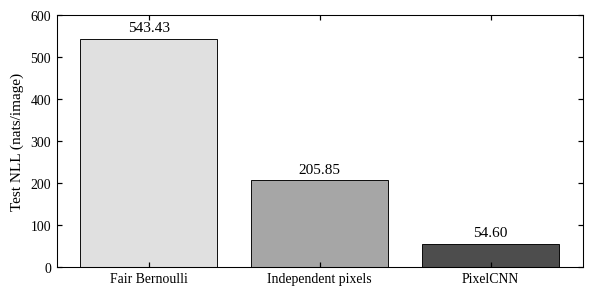

In [12]:
train_eval_loader = DataLoader(train_dataset, shuffle=False, **loader_kwargs)
train_metrics, _ = evaluate(model, train_eval_loader)
val_metrics, _ = evaluate(model, val_loader)
test_metrics, test_nll = evaluate(model, test_loader)
np.save(OUT / 'test_nll_per_image.npy', test_nll.numpy())
position_p = (train_x.sum(0,keepdim=True) + 1) / (len(train_x) + 2)
independent_nll = -(test_x * position_p.log() + (1-test_x) * (1-position_p).log()).flatten(1).sum(1).double()
baseline_metrics = dict(fair_bernoulli_nll=784*math.log(2),
                        independent_bernoulli_nll=independent_nll.mean().item(),
                        independent_standard_error=independent_nll.std().item()/math.sqrt(len(independent_nll)))
metrics = dict(train=train_metrics, validation=val_metrics, test=test_metrics,
               baselines=baseline_metrics, **training_summary)
metrics['test_95pct_mean_interval'] = [test_metrics['nll_nats_per_image'] + s*1.96*test_metrics['standard_error'] for s in (-1,1)]
(OUT / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
print(json.dumps(metrics, indent=2))
table = '| Split | N | NLL (nats/image) | BCE (nats/pixel) | bits/pixel |\n|---|---:|---:|---:|---:|\n'
for name, vals in [('Train',train_metrics),('Validation',val_metrics),('Test',test_metrics)]:
    table += f'| {name} | {vals["n"]} | {vals["nll_nats_per_image"]:.4f} | {vals["bce_nats_per_pixel"]:.6f} | {vals["bits_per_pixel"]:.6f} |\n'
display(Markdown(table))
fig, ax = plt.subplots(figsize=(5.5,2.8))
names = ['Fair Bernoulli', 'Independent pixels', 'PixelCNN']
values = [baseline_metrics['fair_bernoulli_nll'], baseline_metrics['independent_bernoulli_nll'],test_metrics['nll_nats_per_image']]
bars = ax.bar(names, values, color=['0.88','0.65','0.3'],edgecolor='black',linewidth=0.6)
ax.bar_label(bars,fmt='%.2f',padding=3)
ax.set(ylabel='Test NLL (nats/image)',ylim=(0,600))
fig.tight_layout(); fig.savefig(FIG/'baseline_comparison.png',dpi=400,bbox_inches='tight')
fig.savefig(FIG/'baseline_comparison.pdf',bbox_inches='tight')
plt.show(); plt.close(fig)

# e. Evaluation (Reconstruction)

以下各位置的条件概率由真实图像前缀确定，图像为相应的条件采样结果。下一部分的无条件生成则使用模型此前采样的像素作为后续上下文。黑色表示像素取值为 1。

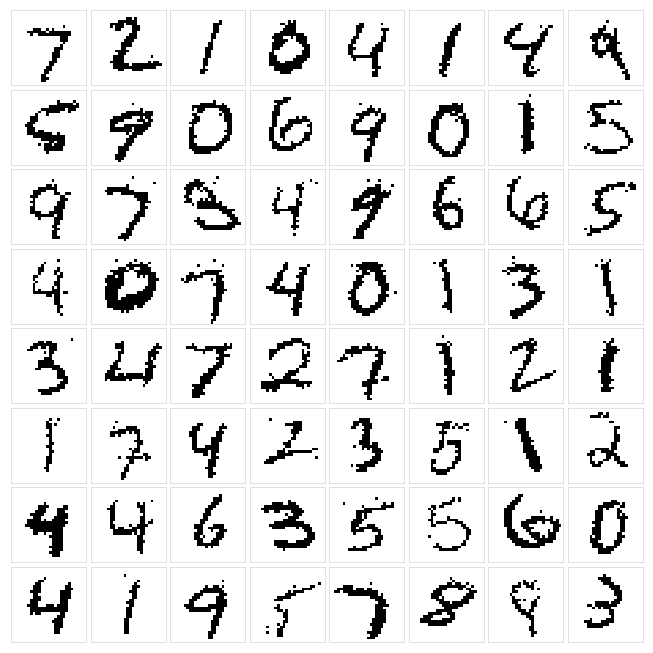

Conditional pixel samples based on observed prefixes; 64 test images.


In [13]:
H, W = 28, 28
model.eval()
images, labels = next(iter(test_loader))
images = images[:64].to(device)
conditional_generator = torch.Generator(device=device).manual_seed(CONFIG['sample_seed']+1)
with torch.no_grad():
    pred = model(images)
    conditional_samples = torch.bernoulli(pred,generator=conditional_generator).cpu()
np.save(OUT/'reconstruction_inputs.npy',images.cpu().numpy())
np.save(OUT/'reconstruction_samples.npy',conditional_samples.numpy())
show_grid(conditional_samples,'conditional_reconstruction.png')
print('Conditional pixel samples based on observed prefixes; 64 test images.')

# f. Evaluation (Generation)

从全零画布出发，按从上到下、从左到右的顺序遍历全部 784 个位置，包括首行和首列。所有无条件采样采用温度 1、种子 20260921，黑色表示像素值 1。

以下分别展示 S1/S2/S3、结构对照中的 S2 与 G，以及 F0/F0.2 的完整 64 张样本，按采样顺序排列。所选模型另展示实际追加第 1 轮样本及逐行生成过程。固定种子控制采样随机性，不要求不同模型在同一格生成相同数字。

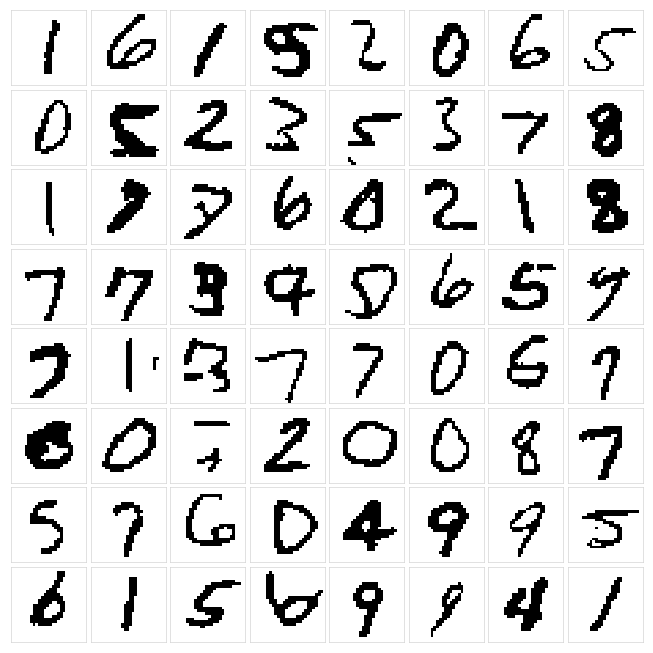

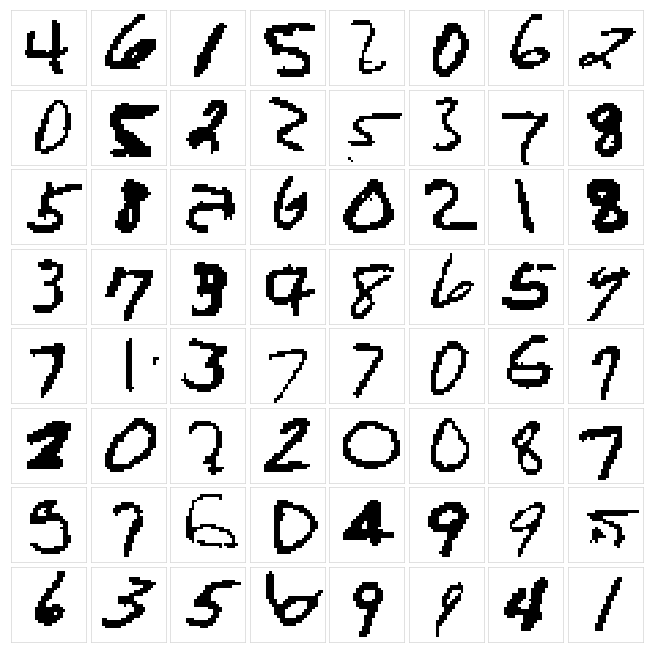

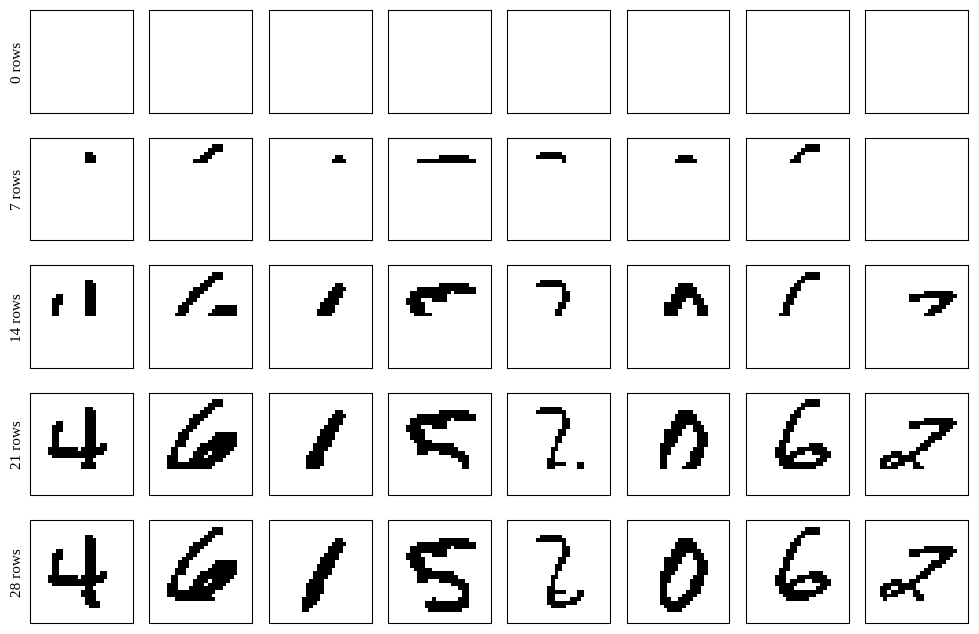

**lr1e-3_bs256 — all 64 samples**

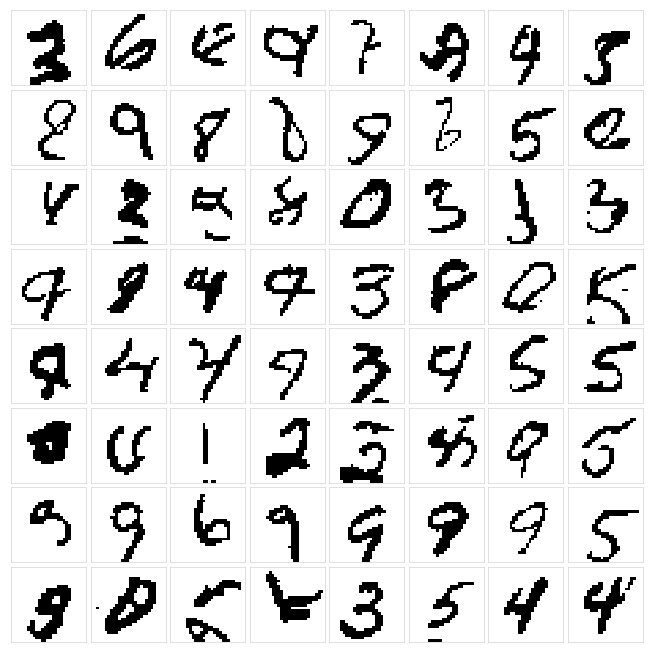

**lr1e-3_bs128 — all 64 samples**

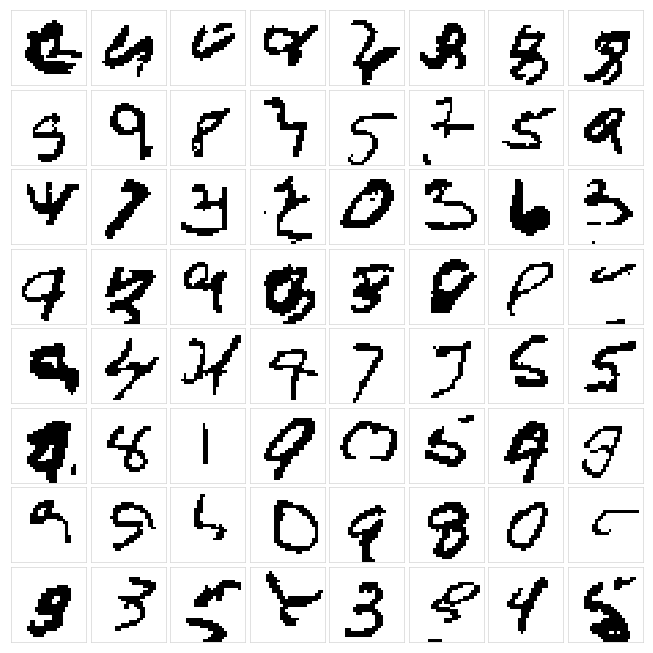

**lr5e-4_bs128 — all 64 samples**

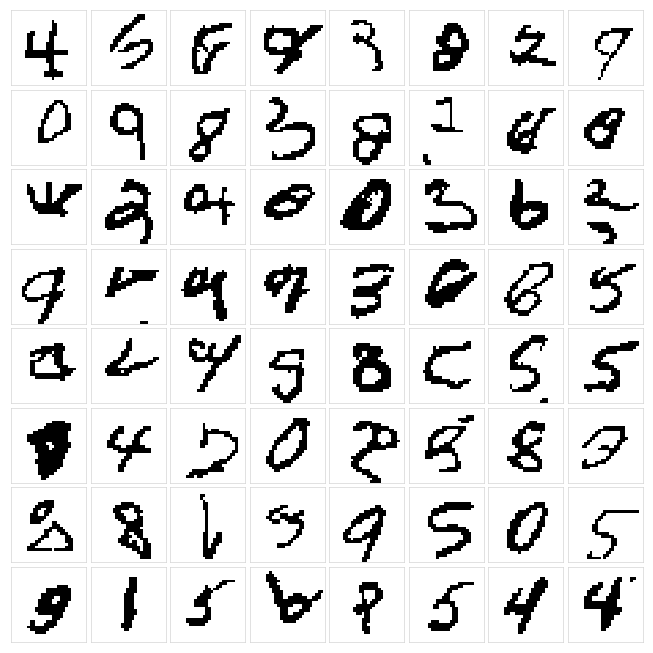

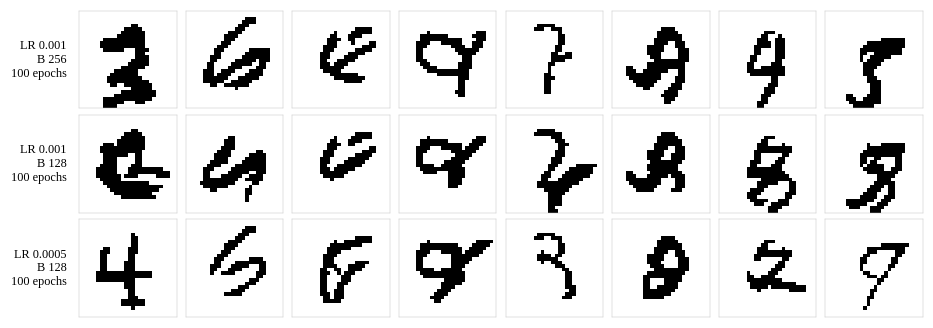

{
  "n_samples": 64,
  "seed": 20260921,
  "temperature": 1.0,
  "seconds": 44.832547664642334,
  "early_seconds": 45.26176171004772,
  "generated_foreground_fraction": 0.14150191843509674,
  "test_foreground_fraction": 0.13422946631908417
}


**Standard PixelCNN — all 64 samples**

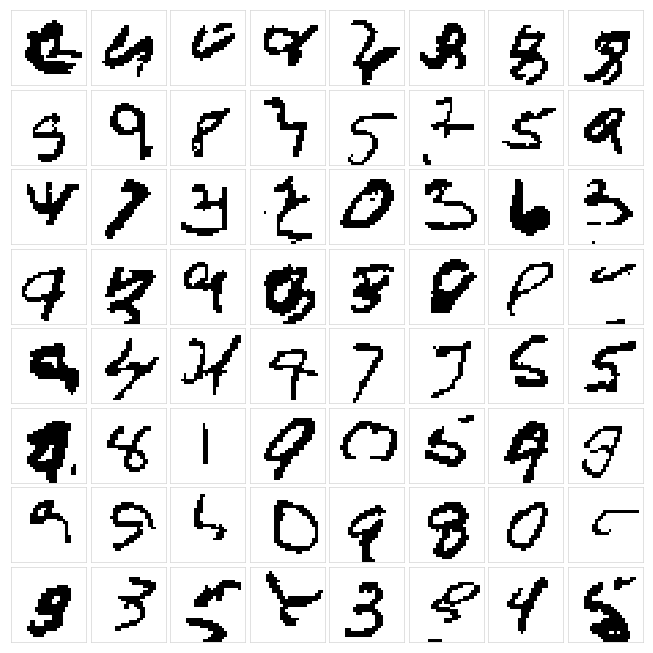

**Dilated gated PixelCNN — all 64 samples**

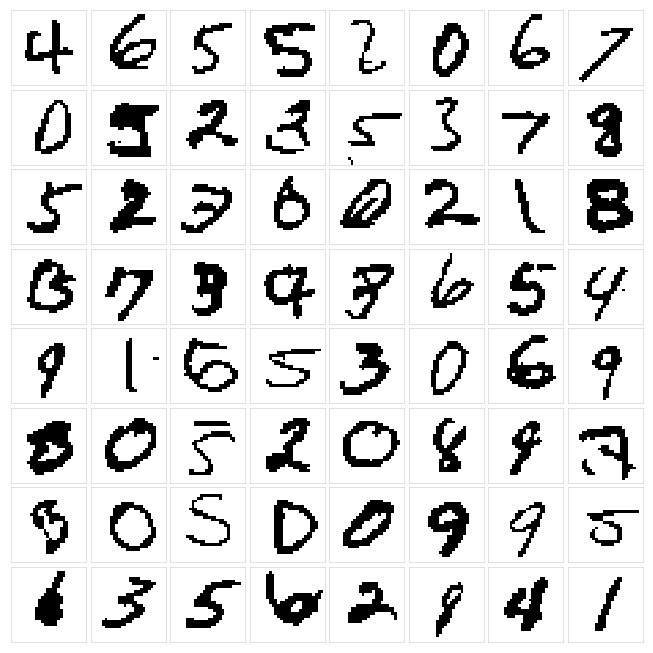

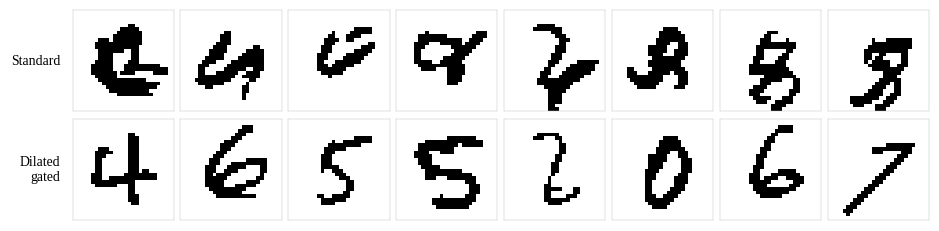

**finetune_control — all 64 samples**

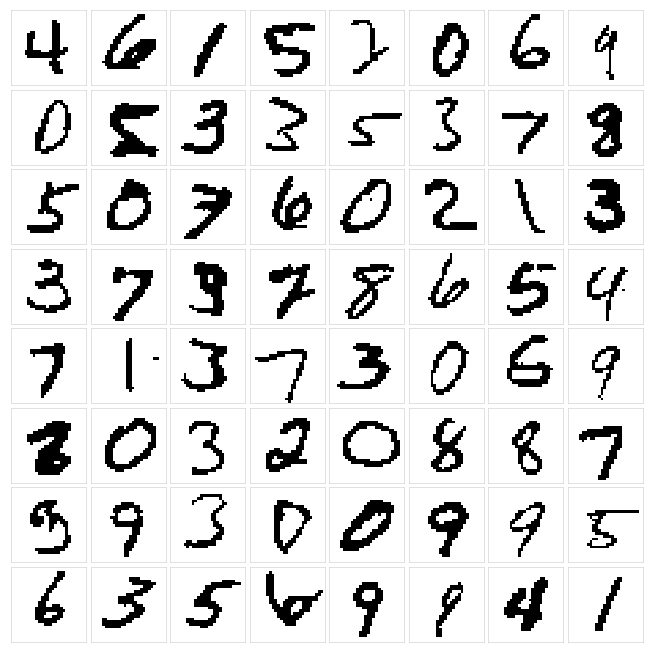

13498

In [14]:
@torch.no_grad()
def sample_images(model, n=64, seed=20260921, capture=False):
    model.eval()
    generator = torch.Generator(device=device).manual_seed(seed)
    images = torch.zeros(n,1,28,28,device=device)
    frames = [images[:8].cpu().clone()] if capture else []
    start = time.perf_counter()
    for row in range(28):
        for col in range(28):
            probability = model(images)[:,0,row,col]
            images[:,0,row,col] = torch.bernoulli(probability, generator=generator)
        if capture and row + 1 in (7,14,21,28):
            frames.append(images[:8].cpu().clone())
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return images.cpu(), frames, time.perf_counter()-start

early = (GatedPixelCNN(CONFIG['channels'], CONFIG['n_blocks'], CONFIG['dilations'])
         if CONFIG['architecture']=='dilated_gated' else PixelCNN(CONFIG['channels'], CONFIG['n_blocks'])).to(device)
early.load_state_dict(torch.load(OUT/'pixelcnn_epoch_01.pt',map_location=device))
early_samples, _, early_seconds = sample_images(early, CONFIG['n_samples'], CONFIG['sample_seed'])
del early
samples, frames, sample_seconds = sample_images(model, CONFIG['n_samples'], CONFIG['sample_seed'], capture=True)
assert samples.shape == (64,1,28,28)
assert set(samples.unique().tolist()) <= {0.,1.}
np.save(OUT/'samples_epoch01.npy',early_samples.numpy())
np.save(OUT/'samples_final.npy',samples.numpy())
np.save(OUT/'sampling_frames.npy',torch.stack(frames).numpy())
show_grid(early_samples,'samples_epoch01.png')
show_grid(samples,'samples_final.png')
fig, axes = plt.subplots(5,8,figsize=(9,6))
for row, (frame, count) in enumerate(zip(frames,(0,7,14,21,28))):
    for col in range(8):
        axes[row,col].imshow(frame[col,0],cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
        axes[row,col].set_xticks([]); axes[row,col].set_yticks([])
    axes[row,0].set_ylabel(f'{count} rows')
# Each column follows the same sample through the raster scan.
fig.tight_layout(); fig.savefig(FIG/'sampling_progress.png',dpi=400,bbox_inches='tight')
plt.show(); plt.close(fig)

# Retain all samples from each candidate; compare fixed first eight.
comparison_images = []
comparison_labels = []
for candidate in CANDIDATES:
    comparison_model = PixelCNN(CONFIG['channels'], CONFIG['n_blocks']).to(device)
    candidate_dir = OUT/'tuning'/candidate['name']
    comparison_model.load_state_dict(torch.load(candidate_dir/'pixelcnn_best.pt', map_location=device))
    candidate_samples, _, _ = sample_images(comparison_model, CONFIG['n_samples'], CONFIG['sample_seed'])
    np.save(candidate_dir/'samples_final.npy', candidate_samples.numpy())
    display(Markdown('**'+candidate['name']+' — all 64 samples**'))
    show_grid(candidate_samples,'samples_'+candidate['name']+'_all64.png')
    comparison_images.append(candidate_samples[:8])
    comparison_labels.append(f'LR {candidate["lr"]:g}\nB {candidate["batch_size"]}\n{tuning_summary["final_epochs"]} epochs')
    del comparison_model
fig, axes = plt.subplots(3, 8, figsize=(9, 2.9))
for row, batch in enumerate(comparison_images):
    for col in range(8):
        axes[row,col].imshow(batch[col,0], cmap='gray_r', vmin=0, vmax=1, interpolation='nearest')
        axes[row,col].set_xticks([]); axes[row,col].set_yticks([])
        for spine in axes[row,col].spines.values():
            spine.set_color('0.76'); spine.set_linewidth(0.3)
    axes[row,0].set_ylabel(comparison_labels[row], fontsize=8, rotation=0, ha='right', va='center', labelpad=8)
fig.subplots_adjust(left=.14, right=.995, bottom=.02, top=.98, wspace=.065, hspace=.07)
fig.savefig(FIG/'tuning_comparison.png', dpi=400, bbox_inches='tight')
plt.show(); plt.close(fig)

sampling_metrics = dict(n_samples=64,seed=CONFIG['sample_seed'],temperature=1.0,
                        seconds=sample_seconds, early_seconds=early_seconds,
                        generated_foreground_fraction=samples.mean().item(),
                        test_foreground_fraction=test_x.mean().item())
(OUT/'sampling_metrics.json').write_text(json.dumps(sampling_metrics,indent=2),encoding='utf-8')
print(json.dumps(sampling_metrics,indent=2))

# Show both complete batches and retain the three standard tuning batches.
all_batches = {}
for label, directory, constructor in [
    ('standard', standard_dir, lambda: PixelCNN(64,12)),
    ('dilated_gated', architecture_dir, lambda: GatedPixelCNN(64,12,ARCH_CONFIG['dilations']))]:
    if selected_fine=='dilated_gated' and label == selected_architecture:
        batch, seconds = samples, sample_seconds
    else:
        comparison_model = constructor().to(device)
        comparison_model.load_state_dict(torch.load(directory/'pixelcnn_best.pt', map_location=device))
        batch, _, seconds = sample_images(comparison_model, 64, CONFIG['sample_seed'])
        del comparison_model
    np.save(directory/'samples_final.npy', batch.numpy())
    current_sampling = dict(n_samples=64, seed=CONFIG['sample_seed'], temperature=1.,
        seconds=seconds, generated_foreground_fraction=batch.mean().item(),
        test_foreground_fraction=test_x.mean().item())
    (directory/'sampling_metrics.json').write_text(json.dumps(current_sampling, indent=2))
    entry = 'baseline' if label=='standard' else 'improved'
    architecture_summary[entry]['sampling_metrics'] = current_sampling
    all_batches[label] = batch
    if selected_fine!='dilated_gated' or label != selected_architecture:
        display(Markdown('**'+('Standard PixelCNN' if label=='standard' else 'Dilated gated PixelCNN')+' — all 64 samples**'))
        show_grid(batch, 'samples_'+label+'_all64.png')
(OUT/'architecture_summary.json').write_text(json.dumps(architecture_summary, indent=2))
fig, axes = plt.subplots(2,8,figsize=(9,1.95))
for row, label in enumerate(('standard','dilated_gated')):
    for col in range(8):
        axes[row,col].imshow(all_batches[label][col,0],cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
        axes[row,col].set_xticks([]);axes[row,col].set_yticks([])
        for spine in axes[row,col].spines.values():
            spine.set_color('0.76');spine.set_linewidth(.3)
    axes[row,0].set_ylabel('Standard' if row==0 else 'Dilated\ngated',fontsize=9,
                          rotation=0,ha='right',va='center',labelpad=8)
fig.subplots_adjust(left=.13,right=.995,bottom=.01,top=.99,wspace=.065,hspace=.07)
fig.savefig(FIG/'architecture_comparison.png',dpi=400,bbox_inches='tight')
plt.show();plt.close(fig)


initial_entry['sampling_metrics']=copy.deepcopy(architecture_summary['improved']['sampling_metrics'])
for entry in fine_entries:
    cfg=entry['config'];directory=OUT/entry['artifact_dir']
    if entry['name']==selected_fine:
        batch,seconds=samples,sample_seconds
    else:
        comparison_model=RegularizedGatedPixelCNN(64,12,cfg['dilations'],cfg['dropout_p']).to(device)
        comparison_model.load_state_dict(torch.load(directory/'pixelcnn_best.pt',map_location=device))
        batch,_,seconds=sample_images(comparison_model,64,CONFIG['sample_seed'])
        del comparison_model
    np.save(directory/'samples_final.npy',batch.numpy())
    entry['sampling_metrics']=dict(n_samples=64,seed=CONFIG['sample_seed'],temperature=1.,seconds=seconds,
        generated_foreground_fraction=batch.mean().item(),test_foreground_fraction=test_x.mean().item())
    (directory/'sampling_metrics.json').write_text(json.dumps(entry['sampling_metrics'],indent=2))
    if entry['name']!=selected_fine:
        display(Markdown('**'+entry['name']+' — all 64 samples**'))
        show_grid(batch,'samples_'+entry['name']+'_all64.png')
finetuning_summary['selected_entry']=(next(e for e in fine_entries if e['name']==selected_fine)
    if selected_fine!='dilated_gated' else initial_entry)
(OUT/'finetuning_summary.json').write_text(json.dumps(finetuning_summary,indent=2))


### 训练后因果性核对

In [15]:

# Compare with the same dropout masks, so stochasticity cannot mimic leakage.
saved_mode=model.training
saved_cpu_rng=torch.get_rng_state()
saved_cuda_rng=torch.cuda.get_rng_state_all() if device.type=='cuda' else []
trained_checks={}
test_prefix=train_x[:2].to(device)
for training in (True,False):
    model.train(training);max_error=0.
    for index in (0,27,28,200,392,783):
        altered=test_prefix.clone();altered.flatten(1)[:,index:]=1-altered.flatten(1)[:,index:]
        matched_cpu_rng=torch.get_rng_state()
        matched_cuda_rng=torch.cuda.get_rng_state_all() if device.type=='cuda' else []
        with torch.no_grad():
            before=model.logits(test_prefix).flatten(1)[:,:index+1]
            torch.set_rng_state(matched_cpu_rng)
            if device.type=='cuda':torch.cuda.set_rng_state_all(matched_cuda_rng)
            after=model.logits(altered).flatten(1)[:,:index+1]
        error=(before-after).abs().max().item();max_error=max(max_error,error)
        assert error<1e-5,'Trained model leaks current/future pixels'
    variable=test_prefix.clone().requires_grad_(True)
    gradient,=torch.autograd.grad(model.logits(variable).flatten(1)[0,392],variable)
    assert torch.count_nonzero(gradient.flatten(1)[0,392:]).item()==0
    trained_checks['train' if training else 'eval']=max_error
model.train(saved_mode)
torch.set_rng_state(saved_cpu_rng)
if device.type=='cuda':torch.cuda.set_rng_state_all(saved_cuda_rng)
CHECKS['trained_28x28_prefix_max_error']=trained_checks
CHECKS['selected_finetuning_future_input_gradient']=0.
(OUT/'correctness_checks.json').write_text(json.dumps(CHECKS,indent=2))
print('Trained selected model prefix invariance with matched dropout:',trained_checks)


Trained selected model prefix invariance with matched dropout: {'train': 0.0, 'eval': 0.0}


### 实验结果与讨论

各阶段记录如下，NLL 单位为 nats/image。“—”表示该候选没有单独报告测试集指标；标准候选的比较与选择依据验证集完成。

| 编号 | 模型与设置 | 实际训练轮数 | 所选检查点 | 验证 NLL | 测试 NLL |
|---|---|---:|---|---:|---:|
| S0 | 标准网络；lr=0.001，batch=256 | 25 | 第 25 轮 | 62.1652 | 62.1889 |
| S1 | 标准网络；lr=0.001，batch=256 | 100 | 第 68 轮 | 60.5759 | — |
| S2 | 标准网络；lr=0.001，batch=128 | 100 | 第 47 轮 | 60.4642 | 60.4827 |
| S3 | 标准网络；lr=0.0005，batch=128 | 100 | 第 45 轮 | 60.5535 | — |
| G | 双支路门控；lr=0.001，batch=128 | 100 | 第 9 轮 | 55.1815 | 55.3111 |
| F0 | 从 G 第 9 轮续训；Dropout=0 | 追加 8 | 追加第 3 轮 EMA | 54.5623 | 54.6944 |
| F0.2 | 从 G 第 9 轮续训；Dropout=0.2 | 追加 9 | 追加第 4 轮 EMA | 54.4841 | 54.6024 |

初始探索 S0 的验证 NLL 为 62.1652。三组标准网络各训练 100 轮后，S2 取得最低验证 NLL 60.4642，对应第 47 轮。门控网络 G 将验证／测试 NLL 降至 55.1815／55.3111；完整训练曲线同时显示其后期过拟合，因此保留第 9 轮检查点用于正则化阶段。F0 与 F0.2 共用这一检查点，分别比较不加 Dropout 和 Dropout 0.2 的低学习率续训。

所选模型 F0.2 的追加第 4 轮 EMA 权重，验证 NLL 为 54.4841，测试 NLL 为 54.6024。相对标准模型 S2，测试 NLL 下降 9.72%；相对门控模型 G，下降 1.28%。对应测试 BCE 为 0.069646 nats/pixel，bpp 为 0.100478。

生成图像与似然共同用于分析结果。标准模型的样本中存在分离笔画，门控模型的部分数字轮廓更完整；所选 F0.2 模型的大多数样本具有可辨认的数字形状，其中也存在孤立像素、过粗笔画和不自然的连接。F0.2 样本的前景比例为 0.1415，测试集为 0.1342。似然、墨迹比例与数字可辨认程度分别反映模型表现的不同方面。

本作业完成了掩码卷积、PixelCNN、交叉熵训练、超参数与结构对照、条件预测及无条件生成。各阶段使用一个固定训练种子，生成图像也来自一个固定采样种子；结果用于说明本实验的表现，不据此判断跨种子稳定性或各结构组件的独立贡献。

### 参考文献

1. PyTorch. BCEWithLogitsLoss. https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html
2. van den Oord A., Kalchbrenner N., Kavukcuoglu K. Pixel Recurrent Neural Networks. ICML, 2016.
3. van den Oord A. et al. Conditional Image Generation with PixelCNN Decoders. NeurIPS, 2016.
4. LeCun Y., Cortes C., Burges C. MNIST database of handwritten digits. https://yann.lecun.org/exdb/mnist/
5. Salimans T., Karpathy A., Chen X., Kingma D. P. PixelCNN++: Improving the PixelCNN with Discretized Logistic Mixture Likelihood and Other Modifications. ICLR, 2017.
